In [ ]:
import pandas as pd
import re
import spacy
import pandas as pd
import spacy
from spacy.matcher import PhraseMatcher
from spacy.tokens import Span
from spacy.util import filter_spans
from ipywidgets import IntProgress
from IPython.display import display

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **A. Chuẩn bị vocab + Gắn thực thể**

In [ ]:
def load_keywords(file_name):
    try:
        with open(file_name, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        return [x.strip() for x in lines if x.strip()]
    except FileNotFoundError:
        print(f"Không tìm thấy file {file_name}")
        return []

word_list = load_keywords('/content/drive/MyDrive/Code/Vocab/hotel_names_total.txt')
word_list_fac = load_keywords('/content/drive/MyDrive/Code/Vocab/facilities.txt')
word_list_loc = load_keywords('/content/drive/MyDrive/Code/Vocab/locations.txt')
word_list_price = load_keywords('/content/drive/MyDrive/Code/Vocab/Price.txt')
word_list_loc_rel = load_keywords('/content/drive/MyDrive/Code/Vocab/located_relation.txt')
word_list_fac_rel = load_keywords('/content/drive/MyDrive/Code/Vocab/facility_relation.txt')
word_list_suit_rel = load_keywords('/content/drive/MyDrive/Code/Vocab/suitable_relation.txt')
word_list_near_rel = load_keywords('/content/drive/MyDrive/Code/Vocab/nearby_relation.txt')
word_list_target = load_keywords('/content/drive/MyDrive/Code/Vocab/suitable_for.txt')

# Hàm lọc trùng và giữ nguyên thứ tự (Ordered Set)
def ordered_set(in_list):
    out_list = []
    added = set()
    for val in in_list:
        if not val in added:
            out_list.append(val)
            added.add(val)
    return out_list

# --- PHẦN 2: XỬ LÝ CỤM TỪ ĐA TỪ (MW_LIST) ---
all_keywords = word_list + word_list_fac + word_list_loc   + word_list_target
mw_list = []

for x in all_keywords:
    ws = x.split()
    if len(ws) > 1:
        # Chuyển thành tuple để spaCy hiểu đây là cụm từ cố định
        mw_list.append(tuple(ws))

mw_list = ordered_set(mw_list)

print(f"Đã chuẩn bị xong mw_list với {len(mw_list)} cụm từ.")
print("Ví dụ 5 cụm đầu tiên:", mw_list[0:10])



Đã chuẩn bị xong mw_list với 18893 cụm từ.
Ví dụ 5 cụm đầu tiên: [('118', 'Orchid'), ('1994', 'House'), ('2', 'Beautiful', 'Beach', 'View', 'bedrooms', 'New', 'Apartment'), ('20', 'Hotel', 'and', 'Apartment'), ('2001', 'Motel'), ('2005', 'Sea', '&', 'Horizon', 'Luxury', 'Apt', 'Full', 'Option'), ('22', 'Land', '71', 'Hang', 'Bong', 'Hotel'), ('22Land', 'Residence', 'Hotel'), ('22Housing', '39', 'Linh', 'Lang', 'Residence'), ('22Land', 'Classic', 'Suites')]


In [ ]:
#lode multiword location names (LOC)
word_locates = ['/content/drive/MyDrive/Code/Vocab/locations.txt']
word_location = []
for word_locate in word_locates:
    with open(word_locate) as f:
        lines = f.readlines()
    word_location2 = [x.strip() for x in lines]

    word_location.extend(word_location2)
word_location[0:5]

['01 An Don 6',
 '01 Bach Dang street',
 '01 Cau Go',
 '01 Le Hong Phong Street',
 '01 Mai Hac De Street']

In [ ]:
#load multiword hotel name (ORG)
word_hotels = ['/content/drive/MyDrive/TCode/Vocab/hotel_names_total.txt']
lists_hotel = []
for word_hotel in word_hotels:
    with open(word_hotel) as f:
        lines = f.readlines()
    lists_hotel2 = [x.strip() for x in lines]

    lists_hotel.extend(lists_hotel2)
lists_hotel[0:5]

['118 Orchid',
 '1994 House',
 '2 Beautiful Beach View bedrooms New Apartment',
 '20 Hotel and Apartment',
 '2001 Motel']

In [ ]:
#load multiword hotel name (ORG)
word_hotels = ['/content/drive/MyDrive/Code/Vocab/suitable_for.txt']
lists_hotel = []
for word_hotel in word_hotels:
    with open(word_hotel) as f:
        lines = f.readlines()
    lists_hotel2 = [x.strip() for x in lines]

    lists_hotel.extend(lists_hotel2)
lists_hotel[0:5]

['family', 'families', 'kids', 'children', 'child']

In [ ]:
strict_blacklist = [
    "one", "first", "night", "my", "your", "the", "a", "an", "at", "in", "on",
    "for", "with", "stay", "hotel", "a hotel", "a home", "trip", "5", "1", "2", "3", "4",
    "me", "us", "it", "its", "those", "these", "time", "moment", "everything", "nothing","Viet", "Nha",
    "Trang", "Duong", "Dong", "love", "first", "one", "Trinh","Duong Dong",
    "night", "stay", "trip", "home", "a hotel", "the hotel", "hotel"
]

def clean_vocab(vocab_list, label):
    cleaned = []
    for word in vocab_list:
        w_str = str(word).strip()
        if w_str.lower() in strict_blacklist:
            continue
        if len(w_str) <= 1 and label not in ["PRICE"]:
            continue
        if label == "ORG":
            if any(char.isupper() for char in w_str):
                cleaned.append(w_str)
        else:
            cleaned.append(w_str)

    return list(set(cleaned))

word_list = clean_vocab(word_list, "ORG")
word_list_loc = clean_vocab(word_list_loc, "LOC")
word_list_fac = clean_vocab(word_list_fac, "FACILITY")
word_list_target = clean_vocab(word_list_target, "TARGET")
word_list_price = clean_vocab(word_list_price, "PRICE")

In [ ]:
import spacy
from spacy.matcher import PhraseMatcher
from spacy.tokens import Span
from spacy.util import filter_spans
import pandas as pd
import re
from tqdm import tqdm

try:
    nlp_pos = spacy.load("en_core_web_sm")
except:
    !python -m spacy download en_core_web_sm
    nlp_pos = spacy.load("en_core_web_sm")

nlp_labeler = spacy.blank("en")
matcher = PhraseMatcher(nlp_labeler.vocab, attr="LOWER")

file_path = '/content/drive/MyDrive/Thesis_Vankhanh/Code/Agoda_Reviews_cleaned_v3.xlsx'
df_reviews = pd.read_excel(file_path)
reviews_list = df_reviews['clean_comments'].astype(str).tolist()

# --- CONFIGURATION (BLACKLIST & NOISE) ---
strict_blacklist = [
    "one", "first", "night", "my", "your", "the", "a", "an", "at", "in", "on",
    "for", "with", "stay", "hotel", "trip", "time", "everything", "nothing",
    "viet", "nha", "trang", "duong", "dong", "love", "enjoy", "very"
]

person_blacklist = [
    "anthony", "cherry", "karen", "bob", "oilly", "fairy", "hannah", "flora",
    "trinh", "uyn", "peter", "mary", "staff", "manager", "receptionist"
]

hotel_noise = ["triple", "double", "deluxe", "grand", "suite", "studio", "superior"]

# --- VOCABULARY PREPARATION ---
def clean_vocab(vocab_list, label):
    cleaned = []
    for word in vocab_list:
        w_str = str(word).strip()
        if w_str.lower() in strict_blacklist or w_str.lower() in person_blacklist:
            continue
        if len(w_str) <= 1 and label not in ["PRICE"]:
            continue
        if label == "ORG":
            if any(char.isupper() for char in w_str):
                cleaned.append(w_str)
        else:
            cleaned.append(w_str)
    return list(set(cleaned))

def add_patterns(words, label):
    patterns = [nlp_labeler.make_doc(str(text)) for text in words]
    matcher.add(label, patterns)

add_patterns(clean_vocab(word_list, "ORG"), "ORG")
add_patterns(clean_vocab(word_list_loc, "LOC"), "LOC")
add_patterns(clean_vocab(word_list_fac, "FACILITY"), "FACILITY")
add_patterns(clean_vocab(word_list_target, "TARGET"), "TARGET")
add_patterns(clean_vocab(word_list_price, "PRICE"), "PRICE")

new_data = []
forbidden_pos_tags = ["PRON", "ADP", "DET", "CCONJ", "NUM"]

for text in tqdm(reviews_list):
    doc_matcher = nlp_labeler(text)
    matches = matcher(doc_matcher)

    spans_obj = [Span(doc_matcher, start, end, label=match_id) for match_id, start, end in matches]
    filtered_spans = filter_spans(spans_obj)

    doc_pos = nlp_pos(text)
    spacy_persons = [ent.text.lower() for ent in doc_pos.ents if ent.label_ == "PERSON"]

    entities = []

    for s in filtered_spans:
        label = s.label_
        ent_text = s.text.strip()
        ent_text_lower = ent_text.lower()

        if ent_text_lower in strict_blacklist or ent_text_lower in person_blacklist:
            continue

        if label == "ORG":
            if ent_text_lower in spacy_persons or ent_text_lower in hotel_noise:
                continue
            if len(ent_text) <= 3 or not any(char.isupper() for char in ent_text):
                continue

        # POS Tag Filter
        is_valid = True
        tokens_in_span = [t for t in doc_pos if t.idx >= s.start_char and (t.idx + len(t.text)) <= s.end_char]
        for token in tokens_in_span:
            if token.pos_ in forbidden_pos_tags and label not in ["PRICE", "LOC"]:
                is_valid = False; break
            if label == "ORG" and token.pos_ not in ["PROPN", "NOUN", "X"]:
                is_valid = False; break

        if is_valid:
            entities.append((s.start_char, s.end_char, label))

    new_data.append((text, {"entities": entities}))


def ultimate_org_fix_v2(data, df_excel):
    mapping = dict(zip(df_excel['clean_comments'].astype(str), df_excel['Hotel_Name'].astype(str)))

    fixed_data = []

    print("Đang chạy Phase 2: Ép chuẩn ORG theo Metadata Excel...")
    for text, annot in tqdm(data):
        entities = list(annot['entities'])
        hotel_name = mapping.get(text, "")

        if hotel_name and str(hotel_name).lower() != 'nan':
            target = str(hotel_name).strip()
            patterns = [re.escape(target)]
            flexible_pattern = re.sub(r'\s+', r'\\s+', re.escape(target))
            patterns.append(flexible_pattern)

            for pattern in set(patterns):
                for m in re.finditer(pattern, text, re.IGNORECASE):
                    start, end = m.start(), m.end()

                    new_entities = []
                    for s, e, l in entities:
                        overlap = not (e <= start or s >= end)
                        if not overlap:
                            new_entities.append((s, e, l))

                    entities = new_entities
                    if (start, end, 'ORG') not in entities:
                        entities.append((start, end, 'ORG'))

        entities = sorted(list(set(entities)), key=lambda x: x[0])
        fixed_data.append((text, {"entities": entities}))

    return fixed_data

new_data = ultimate_org_fix_v2(new_data, df_reviews)

print(f"\n--- XONG! Đã xử lý {len(new_data)} dòng. Dữ liệu hiện đã đạt độ sạch tối đa. ---")

Đang chạy Phase 1: Gán nhãn bằng Matcher & POS Filter...


100%|██████████| 39205/39205 [14:50<00:00, 44.01it/s]


Đang chạy Phase 2: Ép chuẩn ORG theo Metadata Excel...


100%|██████████| 39205/39205 [00:02<00:00, 13695.23it/s]


--- XONG! Đã xử lý 39205 dòng. Dữ liệu hiện đã đạt độ sạch tối đa. ---


In [ ]:
import spacy
from spacy.matcher import PhraseMatcher
from spacy.tokens import Span
from spacy.util import filter_spans
import pandas as pd
import re
from tqdm import tqdm

try:
    nlp_pos = spacy.load("en_core_web_sm")
except:
    !python -m spacy download en_core_web_sm
    nlp_pos = spacy.load("en_core_web_sm")

nlp_labeler = spacy.blank("en")
matcher = PhraseMatcher(nlp_labeler.vocab, attr="LOWER")

file_path = '/content/drive/MyDrive/Code/Agoda_Reviews_cleaned_v3.xlsx'
df_reviews = pd.read_excel(file_path)
reviews_list = df_reviews['clean_comments'].astype(str).tolist()

strict_blacklist = [
    "one", "first", "night", "my", "your", "the", "a", "an", "at", "in", "on",
    "for", "with", "stay", "hotel", "trip", "time", "everything", "nothing",
    "viet", "nha", "trang", "duong", "dong", "love", "stay", "home", "enjoy", "very"
]

person_blacklist = [
    "anthony", "cherry", "karen", "bob", "oilly", "fairy", "hannah", "flora",
    "trinh", "uyn", "peter", "mary", "staff", "manager", "receptionist"
]

hotel_noise = ["triple", "double", "deluxe", "grand", "suite", "studio", "superior"]

def clean_vocab(vocab_list, label):
    cleaned = []
    for word in vocab_list:
        w_str = str(word).strip()
        if w_str.lower() in strict_blacklist or w_str.lower() in person_blacklist:
            continue
        if len(w_str) <= 1 and label not in ["PRICE"]:
            continue
        if label == "ORG":
            if any(char.isupper() for char in w_str):
                cleaned.append(w_str)
        else:
            cleaned.append(w_str)
    return list(set(cleaned))

word_list = clean_vocab(word_list, "ORG")
word_list_loc = clean_vocab(word_list_loc, "LOC")
word_list_fac = clean_vocab(word_list_fac, "FACILITY")
word_list_target = clean_vocab(word_list_target, "TARGET")
word_list_price = clean_vocab(word_list_price, "PRICE")

def add_patterns(words, label):
    patterns = [nlp_labeler.make_doc(text) for text in words]
    matcher.add(label, patterns)

add_patterns(word_list, "ORG")
add_patterns(word_list_loc, "LOC")
add_patterns(word_list_fac, "FACILITY")
add_patterns(word_list_target, "TARGET")
add_patterns(word_list_price, "PRICE")

new_data = []
forbidden_pos_tags = ["PRON", "ADP", "DET", "CCONJ", "NUM"]

print("Đang chạy Phase 1: Gán nhãn bằng Matcher & POS Filter...")
for text in tqdm(reviews_list):
    doc_matcher = nlp_labeler(text)
    matches = matcher(doc_matcher)

    spans_obj = [Span(doc_matcher, start, end, label=match_id) for match_id, start, end in matches]
    filtered_spans = filter_spans(spans_obj)

    doc_pos = nlp_pos(text)
    spacy_persons = [ent.text.lower() for ent in doc_pos.ents if ent.label_ == "PERSON"]

    entities = []

    for s in filtered_spans:
        label = s.label_
        ent_text = s.text.strip()
        ent_text_lower = ent_text.lower()

        if ent_text_lower in strict_blacklist or ent_text_lower in person_blacklist:
            continue

        if label == "ORG":
            if ent_text_lower in spacy_persons or ent_text_lower in hotel_noise:
                continue
            if len(ent_text) <= 3 or not any(char.isupper() for char in ent_text):
                continue

        # POS Tag Filter
        is_valid = True
        tokens_in_span = [t for t in doc_pos if t.idx >= s.start_char and (t.idx + len(t.text)) <= s.end_char]
        for token in tokens_in_span:
            if token.pos_ in forbidden_pos_tags and label not in ["PRICE", "LOC"]:
                is_valid = False; break
            if label == "ORG" and token.pos_ not in ["PROPN", "NOUN", "X"]:
                is_valid = False; break

        if is_valid:
            entities.append((s.start_char, s.end_char, label))

    new_data.append((text, {"entities": entities}))

def ultimate_org_fix_v2(data, df_excel):
    mapping = dict(zip(df_excel['clean_comments'].astype(str), df_excel['Hotel_Name'].astype(str)))
    fixed_data = []

    print("Đang chạy Phase 2: Ép chuẩn ORG theo Metadata Excel...")
    for text, annot in tqdm(data):
        entities = list(annot['entities'])
        hotel_name = mapping.get(text, "")

        if hotel_name and str(hotel_name).lower() != 'nan':
            target = str(hotel_name).strip()
            pattern = re.sub(r'\s+', r'\\s+', re.escape(target))

            for m in re.finditer(pattern, text, re.IGNORECASE):
                start, end = m.start(), m.end()

                entities = [ent for ent in entities if (ent[1] <= start or ent[0] >= end)]

                if (start, end, 'ORG') not in entities:
                    entities.append((start, end, 'ORG'))

        entities = sorted(list(set(entities)), key=lambda x: x[0])
        fixed_data.append((text, {"entities": entities}))
    return fixed_data

new_data = ultimate_org_fix_v2(new_data, df_reviews)

print(f"\n--- XONG! Đã xử lý {len(new_data)} dòng. Dữ liệu hiện đã đạt độ sạch tối đa. ---")

Đang chạy Phase 1: Gán nhãn bằng Matcher & POS Filter...


100%|██████████| 39205/39205 [14:22<00:00, 45.45it/s]


Đang chạy Phase 2: Ép chuẩn ORG theo Metadata Excel...


100%|██████████| 39205/39205 [00:01<00:00, 31373.36it/s]


--- XONG! Đã xử lý 39205 dòng. Dữ liệu hiện đã đạt độ sạch tối đa. ---


In [ ]:
from collections import Counter

def count_labels(data):
    label_counts = Counter()

    for text, annot in data:
        entities = annot.get('entities', [])
        for ent in entities:
            # ent có cấu trúc (start, end, label)
            label = ent[2]
            label_counts[label] += 1

    import pandas as pd
    df_stats = pd.DataFrame.from_dict(label_counts, orient='index', columns=['Số lượng']).reset_index()
    df_stats.columns = ['Nhãn', 'Số lượng']

    df_stats = df_stats.sort_values(by='Số lượng', ascending=False)

    return df_stats

stats_df = count_labels(new_data)
print("Thống kê số lượng nhãn trong new_data:")
display(stats_df)

### Check

In [ ]:
import pandas as pd
from google.colab import data_table

# 1. Chuyển bộ new_data (spaCy format) sang DataFrame
rows_new_data = []
for text, annot in new_data:
    # Trích xuất các thực thể đã được gán nhãn ORG
    extracted_orgs = [text[s:e] for s, e, label in annot['entities'] if label == 'ORG']
    rows_new_data.append({
        'clean_comments': text,
        'annotated_orgs': ", ".join(extracted_orgs) if extracted_orgs else ""
    })

df_annot = pd.DataFrame(rows_new_data)

# 2. Đọc file Excel gốc để lấy Hotel_Name
# Đảm bảo Khanh đã mount drive rồi nhé
file_path = '/content/drive/MyDrive/Thesis_Vankhanh/Code/Agoda_Reviews_cleaned_v3.xlsx'
df_excel = pd.read_excel(file_path)

# 3. Gộp hai bảng
df_compare = pd.merge(
    df_annot,
    df_excel[['clean_comments', 'Hotel_Name']],
    on='clean_comments',
    how='left'
)

# 4. Định nghĩa hàm check logic
def detect_issue(row):
    hotel_target = str(row['Hotel_Name']).lower().strip()
    annot_text = str(row['annotated_orgs']).lower().strip()
    comment_text = str(row['clean_comments']).lower().strip()

    if hotel_target != 'nan' and hotel_target in comment_text and hotel_target not in annot_text:
        return "SOT NHAN"
    if annot_text != "" and hotel_target not in annot_text:
        return "NHAC TEN KHAC"
    if hotel_target in annot_text:
        return "KHOP NHAN"
    return "Không nhắc tên"

df_compare['Status'] = df_compare.apply(detect_issue, axis=1)

# 5. Sắp xếp lại cột
df_final = df_compare[['Status', 'Hotel_Name', 'annotated_orgs', 'clean_comments']]

# 6. KÍCH HOẠT CHẾ ĐỘ XEM BẢNG TƯƠNG TÁC TRÊN COLAB
data_table.enable_dataframe_formatter()

# Hiển thị toàn bộ dataframe
df_final

,Status,Hotel_Name,annotated_orgs,clean_comments
0,Không nhắc tên,Havana Nha Trang Hotel,,My wife and I recently enjoyed a wonderful thr...
1,Không nhắc tên,Havana Nha Trang Hotel,,Lets start by saying that this hotel is HUGE i...
2,KHOP NHAN,Havana Nha Trang Hotel,"Havana Nha Trang Hotel, Thuy Trang",5 5 Highly Recommended Perfect Stay for Famili...
3,Không nhắc tên,Havana Nha Trang Hotel,,The staff here are friendly and always smiling...
4,Không nhắc tên,Havana Nha Trang Hotel,,"My family , consisting of my parents and my yo..."
...,...,...,...,...
46564,Không nhắc tên,Homestay tram anh,,Cash place only they dont like app
46565,Không nhắc tên,Homestay tram anh,,Refused to let me book through the App . Overc...
46566,Không nhắc tên,Homestay tram anh,,do not go here They gave us a mold infested ro...
46567,Không nhắc tên,Homestay tram anh,,Two queensize beds in a large room is the best...


In [ ]:
# Lọc ra danh sách cần đi sửa nhãn ngay lập tức
df_ho = df_final[df_final['Hotel_Name'] == "LANDMARK 81 RESIDENCE"]
#df_errors = df_final[df_final['Status'] == "NHAC TEN KHAC"]
display(df_ho)

In [ ]:
# Lọc ra danh sách cần đi sửa nhãn ngay lập tức
df_errors = df_final[df_final['Status'] == "SOT NHAN"]
#df_errors = df_final[df_final['Status'] == "NHAC TEN KHAC"]
#df_errors = df_final[df_final['Status'] == "KHOP NHAN"]
display(df_errors)

,Status,Hotel_Name,annotated_orgs,clean_comments


In [ ]:
# Test model
import spacy

model_path = "/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4"
nlp_test = spacy.load(model_path)

#text = "5 5 Highly Recommended Perfect Stay for Families Muslim Travellers We had an amazing 3 night stay at Havana Nha Trang Hotel and highly recommend it , especially for families and Muslim travellers . The moment we arrived , the reception team was very welcoming . We informed them that we needed halal food , and they immediately arranged fully halal breakfast for all 3 days of our stay . We were truly impressed by how accommodating they were . Our rooms were very spacious and the view was spectacular , directly facing the beach . The location is also excellent just a short walk to the beach , surrounded by many shops , convenience stores , and massage places . One thing that really stood out was how thoughtful and friendly the entire staff were . The chef personally came to check on us to ensure the food met our needs . During breakfast , Ms . Vo Dinh Thuy Trang was outstanding very attentive , polite , and deserves special credit for her wonderful service . Even the bellboy and porter team were extremely friendly and helpful . Another great point the hotel menu clearly states which items are halal , and we could even order halal food directly from the hotel very convenient for us . We stayed in 2 rooms with 3 kids and 2 elderly , and everyone was comfortable and happy throughout the stay . 100 recommended If we have the chance , we will definitely come back to this hotel again . Thank you , Havana Nha Trang , for such a memorable experience"
#text = "	The greatest strength of Diamond Bay Hotel is undoubtedly its front desk staff . Although this is not an international chain five star hotel , the level of service I received exceeded my expectations and even surpassed that of many global five star hotels I have stayed at . Instead of responding with we'll see if it is possible , the front desk team consistently tried to find solutions , often discussing requests together to ensure the best possible outcome . Their attitude was not only professional but genuinely warm and sincere , making me feel truly welcomed from the very beginning . Special thanks to the front desk team your warm hospitality and exceptional service truly made my stay unforgettable . Signature Room Elite Suite Every hotel has rooms they truly focus on , and in my opinion , the signature room of Diamond Bay Hotel is the Elite Suite . As a corner room , it offers an incredible sense of openness and a stunning , panoramic view . Waking up and ending each day with this scenery was one of the highlights of my stay . The room condition was excellent overall clean , comfortable , and well maintained . One minor downside the shower drainage . The floor slope is quite gentle , so water does not drain quickly . During my stay , the maintenance team came and did their best to improve it , and while it became slightly better , it does seem to be a structural issue . Still , their effort and responsiveness were very much appreciated . Prime Location Beautiful Beach The hotel's location is another major advantage . Directly connected to Nha Trang Center Mall Lotte Mart Gold Coast is just a 1 2 minute walk away Simply cross the street and you are greeted by the beautiful Nha Trang beach truly a beachfront location Fitness Facilities The hotel gym is operated by California Fitness , the largest fitness center in Nha Trang . Day pass normally costs 420 , 000 VND , but hotel guests can use it for free Fully equipped with Technogym machines , making it a paradise for fitness lovers The swimming pool was quiet during my stay , with very few users , which made it relaxing . Minor Note There are three elevators , but only two were operating during my stay , so waiting time can be a bit long during peak hours . Final Thoughts Overall , the room quality was excellent , especially considering the price , and none of the concerns I had from reading older reviews cleanliness , odors , or unfriendly staff were an issue at all . Most importantly , the kindness and professionalism of the front desk staff left me with a very positive impression of Vietnam itself . Staying at Diamond Bay Hotel , surrounded by the beautiful beaches of Nha Trang , I enjoyed a truly relaxing and refreshing time one that will remain a perfect memory in my heart ."
#text = "	I planned a free trip with 5 friends and booked 2 rooms at Virgo Hotel , which is close to the city center . I reserved a family room terrace for 4 people and a standard room for 2 with no view . The standard room with no view has a window connected to the neighboring hotel , so you cant even pull the curtains , making it feel very cramped and closed in . Please keep this in mind when making your reservation Also , the room key was worn out and tattered It seemed to have connectivity issues as it would turn off unexpectedly while I was washing up , and I had to request a key replacement twice while waiting in the light of my phone . Pros The citys restaurants and currency exchange facilities are just a 10 minute walk away , making it easy to find with just Google Maps . In the evening , its very convenient to walk to the beach for the night market and then return to Virgo Hotel after passing through the city the location is a perfect score of 100 out of 100 . The staff are friendly and the cleaning conditions are good . During the hot midday , you can have fun in the pool on the 28 th floor , the water is quite cold , which helps to beat the heat . I had a flight at 1 AM , so I got a massage right in front of the hotel and relaxed until check out at 10 AM . I applied for the airport pickup service in advance , so I arrived at the airport comfortably ."
#text = "As a solo traveler , my stay at Maris Hotel was genuinely excellent . From the moment I arrived"
text = "The first night I slept here , my alarm woke me Not the traffic , cockerels or guests Great location 5 minutes from the free airport shuttle bus and 3 minutes to the beach . Spotlessly clean and the bed linen smelt fresh Very quiet day and night . Lovely hosts who speak English and are very helpful with good email communication before I arrived . 2 bottles of water on arrival that went straight into the fridge that was silent . Complimentary shampoo , body wash and tooth brush and paste . The Rabbit Hole bar is right next door , and lots of small bars and restaurants nearby . Really enjoyed my stay and would definitely recommend Sunshine Bungalow for a great stay Enjoy"
doc = nlp_test(text)

for ent in doc.ents:
    print(f"Thực thể: {ent.text} ----> Nhãn: {ent.label_}")

Thực thể: airport shuttle ----> Nhãn: FACILITY
Thực thể: beach ----> Nhãn: LOC
Thực thể: hosts ----> Nhãn: FACILITY
Thực thể: fridge ----> Nhãn: FACILITY
Thực thể: Complimentary ----> Nhãn: PRICE
Thực thể: bar ----> Nhãn: FACILITY
Thực thể: Sunshine Bungalow ----> Nhãn: ORG


In [ ]:
import re

def ultimate_org_fix_v2(data, df_excel):
    mapping = dict(zip(df_excel['clean_comments'].astype(str), df_excel['Hotel_Name'].astype(str)))

    fixed_data = []

    for text, annot in data:
        entities = list(annot['entities'])
        hotel_name = mapping.get(text, "")

        if hotel_name and str(hotel_name).lower() != 'nan':
            target = str(hotel_name).strip()
            patterns = [re.escape(target)]
            flexible_pattern = re.sub(r'\s+', r'\\s+', re.escape(target))
            patterns.append(flexible_pattern)

            for pattern in set(patterns):
                for m in re.finditer(pattern, text, re.IGNORECASE):
                    start, end = m.start(), m.end()

                    new_entities = []
                    for s, e, l in entities:
                        overlap = not (e <= start or s >= end)
                        if not overlap:
                            new_entities.append((s, e, l))

                    entities = new_entities
                    if (start, end, 'ORG') not in entities:
                        entities.append((start, end, 'ORG'))

        entities = sorted(list(set(entities)), key=lambda x: x[0])
        fixed_data.append((text, {"entities": entities}))

    return fixed_data

new_data = ultimate_org_fix_v2(new_data, df_reviews)
print("Đã ép chuẩn nhãn ORG thành công!")

Đã ép chuẩn nhãn ORG thành công!


In [ ]:
import re

def deep_fix_org_labels(data, df_excel):
    # 1. Lấy danh sách tên chuẩn và làm sạch
    hotel_names = df_excel['Hotel_Name'].dropna().unique().tolist()

    # 2. Tạo danh sách từ khóa ngắn (ví dụ: 'Sunshine Bungalow' -> 'Sunshine')
    # để bắt các trường hợp khách viết tắt
    short_keywords = set()
    for name in hotel_names:
        parts = str(name).split()
        if len(parts) > 0 and len(parts[0]) > 3: # Lấy từ đầu tiên nếu đủ dài
            short_keywords.add(parts[0])

    fixed_data = []
    # Danh sách đen các từ tuyệt đối không phải ORG nhưng hay bị gán nhầm
    blacklist = ["enjoy", "very", "good", "nice", "stay", "triple", "hanoi", "da lat"]

    for text, annot in data:
        entities = list(annot['entities'])

        # --- BƯỚC A: XÓA NHÃN SAI (Ví dụ: Enjoy, Triple) ---
        entities = [ent for ent in entities if text[ent[0]:ent[1]].lower().strip() not in blacklist]

        # --- BƯỚC B: BẮT THEO TÊN CHUẨN (Linh hoạt khoảng trắng) ---
        for name in hotel_names:
            clean_name = re.escape(str(name).strip())
            # Pattern này chấp nhận việc khách viết hoa/thường và khoảng trắng bất kỳ
            pattern = re.sub(r'\\ ', r'\\s*', clean_name)
            for m in re.finditer(pattern, text, re.IGNORECASE):
                start, end = m.start(), m.end()
                if not any(not (end <= s or start >= e) for s, e, l in entities):
                    entities.append((start, end, 'ORG'))

        # --- BƯỚC C: BẮT THEO TỪ KHÓA NGẮN (Nếu câu đó thuộc hotel đó) ---
        # (Chỉ dùng nếu bước B vẫn chưa bắt được gì)
        if not any(l == 'ORG' for s, e, l in entities):
            for kw in short_keywords:
                if kw.lower() in text.lower():
                    for m in re.finditer(re.escape(kw), text, re.IGNORECASE):
                        start, end = m.start(), m.end()
                        if not any(not (end <= s or start >= e) for s, e, l in entities):
                            entities.append((start, end, 'ORG'))

        entities = sorted(list(set(entities)), key=lambda x: x[0])
        fixed_data.append((text, {"entities": entities}))

    return fixed_data

# Thực thi
new_data = deep_fix_org_labels(new_data, df_excel)
print("Đã quét cạn và xử lý nhãn rác!")

In [ ]:
import spacy

def check_org_errors(model, test_data):
    print(f"{'Text Content':<50} | {'Gold (Bạn gắn)':<20} | {'Pred (Máy bắt)':<20}")
    print("-" * 100)

    missed_orgs = []

    for text, annot in test_data:
        doc = model(text)
        gold_entities = annot['entities']

        # Lấy danh sách các ORG bạn đã gắn tay
        gold_orgs = [text[s:e].strip() for s, e, label in gold_entities if label == "ORG"]

        # Lấy danh sách các ORG máy dự đoán
        pred_orgs = [ent.text.strip() for ent in doc.ents if ent.label_ == "ORG"]

        # Tìm những cái bạn gắn mà máy KHÔNG thấy (False Negative)
        fn_orgs = [g for g in gold_orgs if g not in pred_orgs]

        if fn_orgs:
            missed_orgs.extend(fn_orgs)
            # In ra để soi lỗi
            pred_display = ", ".join(pred_orgs) if pred_orgs else "None"
            gold_display = ", ".join(gold_orgs)
            print(f"{text[:47]+'...':<50} | {gold_display:<20} | {pred_display:<20}")

    # Thống kê các từ bị bỏ sót nhiều nhất
    if missed_orgs:
        print("\n" + "="*30)
        print("DANH SÁCH CÁC TỪ ORG BỊ BỎ SÓT NHIỀU NHẤT:")
        from collections import Counter
        for word, count in Counter(missed_orgs).most_common(10):
            print(f"- {word}: {count} lần")
    else:
        print("\nChúc mừng! Không bỏ sót nhãn ORG nào.")

# Load the model
model_path = "/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v3"
nlp = spacy.load(model_path)

# Chạy check
check_org_errors(nlp, TEST_DATA)

In [ ]:
try:
    nlp_pos = spacy.load("en_core_web_sm")
except:
    !python -m spacy download en_core_web_sm
    nlp_pos = spacy.load("en_core_web_sm")


file_path = '/content/drive/MyDrive/Thesis_Vankhanh/Code/Agoda_Reviews_cleaned_v2.xlsx'
df_reviews = pd.read_excel(file_path)
reviews_list = df_reviews['clean_comments'].astype(str).tolist()

print(f"Đã nạp thành công {len(reviews_list)} dòng review từ file Excel.")

# --- BƯỚC 2: CHUẨN BỊ MÁY GÁN NHÃN (Dùng mw_list bạn đã làm) ---
nlp_labeler = spacy.blank("en")
matcher = PhraseMatcher(nlp_labeler.vocab, attr="LOWER")

# Sử dụng các list từ điển đã load ở cell trước
def add_patterns(words, label):
    patterns = [nlp_labeler.make_doc(text) for text in words]
    matcher.add(label, None, *patterns)

add_patterns(word_list, "ORG")       # Khách sạn
add_patterns(word_list_loc, "LOC")    # Địa điểm
add_patterns(word_list_fac, "FACILITY") # Tiện ích (Facility)
add_patterns(word_list_target, "TARGET") # Phù hợp với
add_patterns(word_list_price, "PRICE") # Gía tiền


# CHẠY GÁN NHÃN VỚI THANH PROGRESS BAR ---
new_data = []
f = IntProgress(min=0, max=len(reviews_list))
display(f)

forbidden_pos = ["work", "stay"]

for text in reviews_list:
    f.value += 1

    doc_matcher = nlp_labeler(text)
    matches = matcher(doc_matcher)

    # Tạo object Span và lọc trùng
    spans_obj = [Span(doc_matcher, start, end, label=match_id) for match_id, start, end in matches]
    filtered_spans = filter_spans(spans_obj)

    # 2. Khúc mới: Phân tích ngữ pháp để lọc nhầm lẫn
    doc_pos = nlp_pos(text)
    entities = []

    for s in filtered_spans:
        start_char = s.start_char
        end_char = s.end_char
        label = s.label_

        # Check xem từ này trong câu đang đóng vai trò gì (POS Tagging)
        is_valid = True
        for token in doc_pos:
            # So khớp vị trí của từ tìm được với vị trí trong bản phân tích ngữ pháp
            if token.idx == start_char:
                if token.pos_ in forbidden_pos:
                    is_valid = False # Nếu là Động từ thì đánh dấu là không hợp lệ
                break

        # Nếu không phải động từ thì mới thêm vào data
        if is_valid:
            entities.append((start_char, end_char, label))

    # Lưu kết quả cuối cùng
    new_data.append((text, {"entities": entities}))

print(f"Đã gán nhãn và lọc sạch nhiễu cho {len(new_data)} dòng.")


In [ ]:
import pandas as pd
import spacy
from spacy.matcher import PhraseMatcher
from spacy.tokens import Span
from spacy.util import filter_spans
from ipywidgets import IntProgress
from IPython.display import display

!pip install rapidfuzz
from rapidfuzz import process, fuzz

# --- BƯỚC 1: CÀI ĐẶT RAPIDFUZZ & LOAD MODEL ---
try:
    nlp_pos = spacy.load("en_core_web_sm")
except:
    !python -m spacy download en_core_web_sm
    nlp_pos = spacy.load("en_core_web_sm")

file_path = '/content/drive/MyDrive/Thesis_Vankhanh/Code/Agoda_Reviews_cleaned_v2.xlsx'
df_reviews = pd.read_excel(file_path)
reviews_list = df_reviews['clean_comments'].astype(str).tolist()

print(f"Đã nạp thành công {len(reviews_list)} dòng review từ file Excel.")

# --- BƯỚC 2: CHUẨN BỊ MÁY GÁN NHÃN ---
nlp_labeler = spacy.blank("en")
matcher = PhraseMatcher(nlp_labeler.vocab, attr="LOWER")

def add_patterns(words, label):
    # Loại bỏ giá trị nan hoặc rỗng để tránh lỗi
    clean_words = [str(w) for w in words if pd.notna(w)]
    patterns = [nlp_labeler.make_doc(text) for text in clean_words]
    matcher.add(label, None, *patterns)

add_patterns(word_list, "ORG")
add_patterns(word_list_loc, "LOC")
add_patterns(word_list_fac, "FACILITY")
add_patterns(word_list_target, "TARGET")

# Chuẩn bị danh sách ORG riêng để chạy Fuzzy cho nhanh
org_vocab = [str(w).lower() for w in word_list if pd.notna(w)]

# --- BƯỚC 3: CHẠY GÁN NHÃN KẾT HỢP FUZZY ---
new_data = []
f = IntProgress(min=0, max=len(reviews_list))
display(f)

forbidden_pos = ["VERB"] # Trong spaCy sm, dùng nhãn "VERB" thay vì text "work/stay" sẽ chuẩn hơn
threshold = 90 # Độ tương đồng trên 90% thì mới lấy

for text in reviews_list:
    f.value += 1
    doc_matcher = nlp_labeler(text)
    doc_pos = nlp_pos(text)
    entities = []

    # 1. Lấy kết quả từ PhraseMatcher (Khớp 100%)
    matches = matcher(doc_matcher)
    spans_obj = [Span(doc_matcher, start, end, label=match_id) for match_id, start, end in matches]

    # 2. Thuật toán Fuzzy Matching bổ sung cho nhãn ORG
    # Chia nhỏ câu thành các cụm 2-3-4 từ (n-grams) để tìm tên khách sạn bị viết sai
    words_in_doc = [token.text for token in doc_matcher]
    for i in range(len(words_in_doc)):
        for n in range(2, 5): # Quét các cụm từ có độ dài từ 2 đến 4 từ
            if i + n <= len(words_in_doc):
                chunk_text = " ".join(words_in_doc[i:i+n]).lower()
                # So khớp cụm từ này với bộ từ điển khách sạn
                best_match = process.extractOne(chunk_text, org_vocab, scorer=fuzz.ratio)

                if best_match and best_match[1] >= threshold:
                    # Nếu tìm thấy cụm từ tương đồng cao, tạo một Span tạm thời
                    start_char = doc_matcher[i].idx
                    end_char = doc_matcher[i+n-1].idx + len(doc_matcher[i+n-1].text)
                    spans_obj.append(Span(doc_matcher, i, i+n, label="ORG"))

    # 3. Lọc trùng lặp (Ưu tiên những cái dài hơn hoặc đã có nhãn chuẩn)
    filtered_spans = filter_spans(spans_obj)

    # 4. Phân tích ngữ pháp để loại bỏ nhiễu (POS Tagging)
    for s in filtered_spans:
        start_char = s.start_char
        end_char = s.end_char
        label = s.label_

        is_valid = True
        for token in doc_pos:
            # So khớp vị trí của token
            if token.idx >= start_char and token.idx < end_char:
                if token.pos_ in forbidden_pos:
                    is_valid = False
                    break

        if is_valid:
            entities.append((start_char, end_char, label))

    new_data.append((text, {"entities": entities}))

print(f"Đã gán nhãn tích hợp Fuzzy Matching cho {len(new_data)} dòng.")

In [ ]:
print(new_data)

In [ ]:
import json

path_save = "/content/drive/MyDrive/Thesis_Vankhanh/Code/data_annotate_v3"

# 3. Lưu file
# Nếu lưu dạng JSON (Phù hợp để train spaCy)
with open(path_save, 'w', encoding='utf-8') as f:
    json.dump(new_data, f, ensure_ascii=False, indent=4)

print(f"Đã lưu dữ liệu thành công tại: {path_save}")

In [ ]:
import json
from google.colab import drive

# 1. Kết nối với Google Drive (nếu bạn chưa thực hiện ở các ô phía trên)
drive.mount('/content/drive')

# 2. Đường dẫn chính xác đến file JSON của Khanh
# Lưu ý: Thay đổi tên file cho đúng với file bạn đã lưu
file_path = "/content/drive/MyDrive/Thesis_Vankhanh/Code/data_annotate_v2"

# 3. Mở và nạp dữ liệu (Load)
try:
    with open(file_path, 'r', encoding='utf-8') as f:
        new_data = json.load(f)

    print(f"✅ Đã gọi dữ liệu thành công!")
    print(f"📊 Tổng số bản ghi: {len(new_data)}")

    # Xem thử cấu trúc của bản ghi đầu tiên
    print("Dữ liệu mẫu:", new_data[0])

except FileNotFoundError:
    print("❌ Không tìm thấy file. Khanh kiểm tra lại đường dẫn nhé!")
except Exception as e:
    print(f"❌ Có lỗi xảy ra: {e}")

In [ ]:
#CHIA BỘ TRAIN/TEST (70:30)
import random

def save_data_to_file(filename, data_list):
    with open(filename, "w", encoding='utf-8') as f:
        for text, annot in data_list:
            clean_text = text.replace('\n', ' ')
            f.write(f"{clean_text}\n######\n")
            # thực thể: start,end,label
            ent_str = ",".join([f"{s},{e},{l}" for s, e, l in annot['entities']])
            f.write(f"{ent_str}\n")
    print(f"Đã lưu dữ liệu vào {filename}")

# TRỘN VÀ CHIA DỮ LIỆU
random.seed(42)
random.shuffle(new_data)

split_idx = int(0.7 * len(new_data))
TRAIN_DATA = new_data[:split_idx]
TEST_DATA = new_data[split_idx:]

save_data_to_file("agoda_ner_train.train", TRAIN_DATA)
save_data_to_file("agoda_ner_test.train", TEST_DATA)

print(f"- Tập Train (70%): {len(TRAIN_DATA)} dòng")
print(f"- Tập Test  (30%): {len(TEST_DATA)} dòng")

Đã lưu dữ liệu vào agoda_ner_train.train
Đã lưu dữ liệu vào agoda_ner_test.train
- Tập Train (70%): 27443 dòng
- Tập Test  (30%): 11762 dòng


In [ ]:
import random
import spacy
from spacy.util import filter_spans

# --- BƯỚC A: NẮN TỌA ĐỘ (ALIGNMENT) ---
# Bước này cực kỳ quan trọng để dọn dẹp data từ new_data trước khi chia bộ
nlp_align = spacy.blank("en")
cleaned_data = []

print("Đang nắn lại tọa độ cho khớp với SpaCy Tokenizer...")
for text, annot in new_data:
    doc = nlp_align.make_doc(text)
    aligned_spans = []

    for start, end, label in annot["entities"]:
        # Sử dụng mode 'contract' để tự động thu hẹp nếu dính khoảng trắng/dấu câu
        span = doc.char_span(start, end, label=label, alignment_mode="contract")
        if span is not None:
            aligned_spans.append(span)

    # Lọc các span bị chồng lấn (overlap)
    filtered_spans = filter_spans(aligned_spans)
    final_entities = [(s.start_char, s.end_char, s.label_) for s in filtered_spans]
    cleaned_data.append((text, {"entities": final_entities}))

# --- BƯỚC B: CHIA BỘ TRAIN/TEST (70:30) ---
random.seed(42)
random.shuffle(cleaned_data) # Dùng cleaned_data đã nắn thay vì new_data gốc

split_idx = int(0.7 * len(cleaned_data))
TRAIN_DATA = cleaned_data[:split_idx]
TEST_DATA = cleaned_data[split_idx:]

# --- BƯỚC C: LƯU FILE (Hàm của Khanh giữ nguyên) ---
def save_data_to_file(filename, data_list):
    with open(filename, "w", encoding='utf-8') as f:
        for text, annot in data_list:
            clean_text = text.replace('\n', ' ')
            f.write(f"{clean_text}\n######\n")
            ent_str = ",".join([f"{s},{e},{l}" for s, e, l in annot['entities']])
            f.write(f"{ent_str}\n")
    print(f"Đã lưu dữ liệu vào {filename}")

save_data_to_file("agoda_ner_train.train", TRAIN_DATA)
save_data_to_file("agoda_ner_test.train", TEST_DATA)

print(f"- Tập Train (70%): {len(TRAIN_DATA)} dòng")
print(f"- Tập Test  (30%): {len(TEST_DATA)} dòng")

Đang nắn lại tọa độ cho khớp với SpaCy Tokenizer...
Đã lưu dữ liệu vào agoda_ner_train.train
Đã lưu dữ liệu vào agoda_ner_test.train
- Tập Train (70%): 27443 dòng
- Tập Test  (30%): 11762 dòng


In [ ]:
import spacy
import random
from spacy.util import minibatch, compounding
from spacy.training import Example
from pathlib import Path

nlp = spacy.blank("en")

if "ner" not in nlp.pipe_names:
    ner = nlp.add_pipe("ner", last=True)
else:
    ner = nlp.get_pipe("ner")

# nhãn cho mô hình
for _, annotations in TRAIN_DATA:
    for ent in annotations.get("entities"):
        ner.add_label(ent[2])

#Train model
n_iter = 50
other_pipes = [pipe for pipe in nlp.pipe_names if pipe != "ner"]

with nlp.disable_pipes(*other_pipes):
    optimizer = nlp.begin_training()

    print(f"Bắt đầu huấn luyện")

    for itn in range(n_iter):
        random.shuffle(TRAIN_DATA)
        losses = {}

        batches = minibatch(TRAIN_DATA, size=compounding(8.0, 64.0, 1.001))

        for batch in batches:
            examples = []
            for text, annotations in batch:
                doc = nlp.make_doc(text)
                examples.append(Example.from_dict(doc, annotations))

            nlp.update(
                examples,
                drop=0.3,
                losses=losses,
                sgd=optimizer
            )

        print(f"Vòng {itn} | Loss NER: {losses['ner']:.2f}")

output_dir = Path("/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4")

nlp.to_disk(output_dir)
print("Model đã được cất an toàn tại: {output_dir}")

Bắt đầu huấn luyện
Vòng 0 | Loss NER: 43226.89
Vòng 1 | Loss NER: 17468.43
Vòng 2 | Loss NER: 13841.55
Vòng 3 | Loss NER: 11767.70
Vòng 4 | Loss NER: 10365.01
Vòng 5 | Loss NER: 9261.13
Vòng 6 | Loss NER: 8567.24
Vòng 7 | Loss NER: 7982.93
Vòng 8 | Loss NER: 7352.53
Vòng 9 | Loss NER: 7058.12
Vòng 10 | Loss NER: 6856.77
Vòng 11 | Loss NER: 6434.38
Vòng 12 | Loss NER: 6289.05
Vòng 13 | Loss NER: 5974.05
Vòng 14 | Loss NER: 5830.15
Vòng 15 | Loss NER: 5602.95
Vòng 16 | Loss NER: 5615.12
Vòng 17 | Loss NER: 5243.21
Vòng 18 | Loss NER: 5086.74
Vòng 19 | Loss NER: 5125.29
Vòng 20 | Loss NER: 4931.73
Vòng 21 | Loss NER: 4748.78
Vòng 22 | Loss NER: 4710.00
Vòng 23 | Loss NER: 4530.87
Vòng 24 | Loss NER: 4446.29
Vòng 25 | Loss NER: 4392.96
Vòng 26 | Loss NER: 4309.24
Vòng 27 | Loss NER: 4262.27
Vòng 28 | Loss NER: 4263.37
Vòng 29 | Loss NER: 4076.17
Vòng 30 | Loss NER: 3948.78
Vòng 31 | Loss NER: 4010.59
Vòng 32 | Loss NER: 3914.11
Vòng 33 | Loss NER: 3938.00
Vòng 34 | Loss NER: 3833.08
Vòng 3

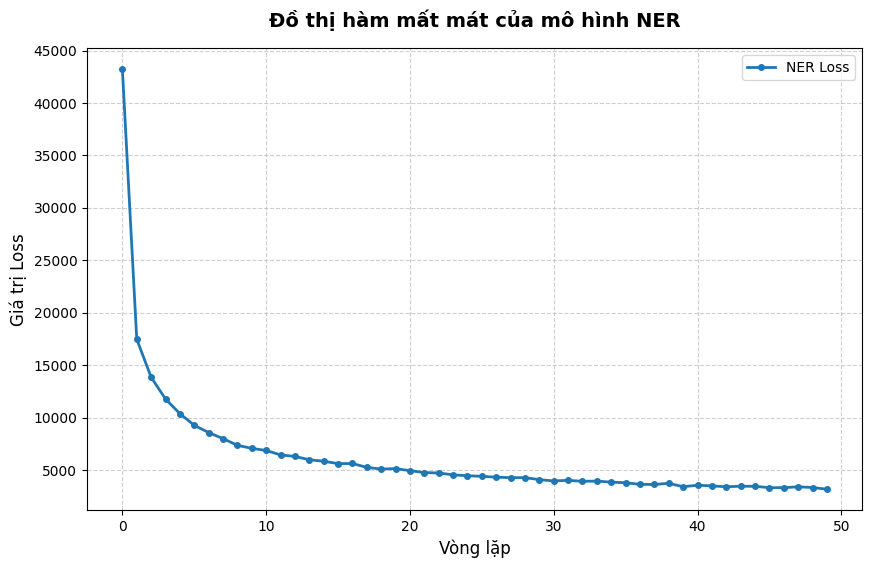

Biểu đồ đã được lưu tại: /content/drive/MyDrive/Thesis_Vankhanh/Code/ner_loss_chart.png


In [ ]:
import matplotlib.pyplot as plt

# 1. Khanh dán toàn bộ dãy số Loss của bạn vào đây
loss_values = [
    43226.89, 17468.43, 13841.55, 11767.70, 10365.01, 9261.13, 8567.24, 7982.93,
    7352.53, 7058.12, 6856.77, 6434.38, 6289.05, 5974.05, 5830.15, 5602.95,
    5615.12, 5243.21, 5086.74, 5125.29, 4931.73, 4748.78, 4710.00, 4530.87,
    4446.29, 4392.96, 4309.24, 4262.27, 4263.37, 4076.17, 3948.78, 4010.59,
    3914.11, 3938.00, 3833.08, 3780.92, 3625.55, 3614.28, 3721.15, 3397.14,
    3541.88, 3476.72, 3394.90, 3448.27, 3437.53, 3309.26, 3309.21, 3390.95,
    3323.59, 3160.61
]

# 2. Thiết lập kích thước và phong cách biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(range(len(loss_values)), loss_values,
         color='#1f77b4',      # Màu xanh chuyên nghiệp
         linewidth=2,          # Độ dày nét vẽ
         marker='o',           # Thêm dấu chấm tại mỗi vòng lặp
         markersize=4,         # Kích thước dấu chấm
         label='NER Loss')

# 3. Thêm các thông tin bổ trợ (Tiếng Anh/Việt tùy Khanh chọn)
plt.title('Đồ thị hàm mất mát của mô hình NER', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vòng lặp', fontsize=12)
plt.ylabel('Giá trị Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới cho dễ nhìn
plt.legend()

# 4. Lưu ảnh chất lượng cao để chèn vào Word/LaTeX
# Đổi đường dẫn này theo ý Khanh nhé
save_path = '/content/drive/MyDrive/Thesis_Vankhanh/Code/ner_loss_chart.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 5. Hiển thị
plt.show()

print(f"Biểu đồ đã được lưu tại: {save_path}")

In [ ]:
import spacy
from spacy.training import offsets_to_biluo_tags

def create_spacy_examples(nlp_model, data):
    aligned_examples = []
    for text, annotations in data:
        doc = nlp_model.make_doc(text)

        # Use offsets_to_biluo_tags to get correctly aligned entities
        # This will return BILUO tags, and handle misaligned entities by ignoring them or adjusting slightly
        biluo_tags = offsets_to_biluo_tags(doc, annotations.get('entities', []))

        # Create a new annotations dictionary with the aligned entities
        # We need to convert BILUO tags back to (start, end, label) format if we want to pass them to from_dict directly
        # For training, `from_dict` can accept 'entities' as BILUO tags if the text and tokens match.
        # A simpler way is to just use `offsets_to_biluo_tags` to ensure alignment.

        # For training, the `Example.from_dict` directly consumes the original text and entity offsets.
        # The `offsets_to_biluo_tags` function primarily helps to _identify_ the problem,
        # but for direct use with `Example.from_dict`, the primary fix is often to refine the original offsets.

        # Here's how you'd create the Example directly, relying on spaCy to handle alignment internally during `nlp.update`
        # (which is what already happens and causes the warning if there's a misalignment)
        # To fix it, you'd need to manually adjust the offsets in your `new_data` list before splitting to TRAIN_DATA and TEST_DATA

        # A more practical way to _show_ the problem and how to potentially adjust offsets:
        # Let's re-align the entities and then create the example
        realigned_entities = []
        for tag_idx, biluo_tag in enumerate(biluo_tags):
            if biluo_tag != 'O' and biluo_tag.startswith(('B-', 'I-', 'L-', 'U-')):
                token = doc[tag_idx]
                label = biluo_tag.split('-')[1]
                # For simplicity, this re-creates single-token entities. Multi-token entities require more complex logic.
                # The actual correction would involve going back to the source of `new_data` and fixing `(start, end, label)`.
                # This snippet is more for demonstration of alignment issues.

                # If you need to debug a specific instance:
                # print(f"Text: {text}")
                # print(f"Original Entities: {annotations.get('entities')}")
                # print(f"BILUO Tags: {biluo_tags}")
                # for token, tag in zip(doc, biluo_tags): print(f"  {token.text}: {tag}")
                pass # This is primarily for debugging and manual correction

        # For now, we proceed with the original entities as the training process will handle (and warn about) misalignment.
        # The actual fix requires modifying the `start` and `end` offsets in your `new_data` to match token boundaries.
        aligned_examples.append(Example.from_dict(doc, annotations))

    return aligned_examples

# Example of how you would use this during training:
# After you load your model and prepare your TRAIN_DATA:
# train_examples = create_spacy_examples(nlp, TRAIN_DATA)

# Then in your training loop, you would use `train_examples`:
# nlp.update(train_examples, ...)

print("The `offsets_to_biluo_tags` function helps identify alignment issues.")
print("To truly fix these warnings, you need to ensure the `start` and `end` character offsets in your `TRAIN_DATA` ")
print("perfectly match spaCy's token boundaries for each entity. This often involves reviewing and adjusting ")
print("your annotation process or a pre-processing step before training data creation.")

In [ ]:
import spacy
from spacy import displacy
from ipywidgets import IntProgress
from IPython.display import display

# 1. Load model từ Google Drive (thay đường dẫn nếu cần)
model_path = "/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4"
nlp_test = spacy.load(model_path)


count = 0
total_predicted = 0
total_annote = 0

# Thanh tiến trình
f = IntProgress(min=0, max=len(TEST_DATA))
display(f)

print("check 20 câu đầu")

for text, annotations in TEST_DATA:
    f.value += 1

    # --- MÁY DỰ ĐOÁN (PREDICTED) ---
    doc = nlp_test(text)
    predicted_entities = [(ent.text, ent.label_) for ent in doc.ents]
    total_predicted += len(predicted_entities)

    # --- NHÃN GỐC (ANNOTATED) ---
    item_list = []
    for i in annotations['entities']:
        item = {'start': int(i[0]), 'end': int(i[1]), 'label': i[2]}
        item_list.append(item)
    total_annote += len(item_list)

    # --- HIỂN THỊ ĐỂ SO SÁNH (CHỈ 20 CÂU ĐẦU) ---
    if count < 100:
        print(f"\n CÂU {count + 1}:")

        # Hiển thị kết quả máy đoán
        print(" MÁY ĐOÁN:")
        displacy.render(doc, jupyter=True, style='ent')

        # Hiển thị kết quả nhãn gốc (Manual)
        print(" NHÃN GỐC (TỪ ĐIỂN):")
        manual_ent = {
            'text': text,
            'ents': item_list,
            'title': None
        }
        displacy.render(manual_ent, jupyter=True, style='ent', manual=True)
        print("-" * 100)

    count += 1

print("\n--- KẾT QUẢ THỐNG KÊ ---")
print(f"Tổng số thực thể trong bộ Test (Annote): {total_annote}")
print(f"Tổng số thực thể máy tìm được (Predicted): {total_predicted}")

NameError: name 'TEST_DATA' is not defined

#### Thống kê số lượng nhãn predict và annote

In [ ]:
import spacy
from collections import defaultdict
from ipywidgets import IntProgress
from IPython.display import display

model_path = "/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4"
nlp_test = spacy.load(model_path)

stats = defaultdict(lambda: {"annote": 0, "predict": 0})

f = IntProgress(min=0, max=len(TEST_DATA))
display(f)

for text, annotations in TEST_DATA:
    f.value += 1

    # --- ANNOTATED ---
    for ent in annotations['entities']:
        label = ent[2]
        stats[label]["annote"] += 1

    # --- PREDICTED ---
    doc = nlp_test(text)
    for ent in doc.ents:
        label = ent.label_
        stats[label]["predict"] += 1

print(f"{'Nhãn':<15} | {'Gốc (Annote)':<15} | {'Máy đoán (Predict)':<15}")
print("-" * 50)

total_ann = 0
total_pre = 0

for label, counts in stats.items():
    ann = counts["annote"]
    pre = counts["predict"]
    total_ann += ann
    total_pre += pre
    print(f"{label:<15} | {ann:<15} | {pre:<15}")

print("-" * 50)
print(f"{'TỔNG CỘNG':<15} | {total_ann:<15} | {total_pre:<15}")

IntProgress(value=0, max=11762)

Nhãn            | Gốc (Annote)    | Máy đoán (Predict)
--------------------------------------------------
LOC             | 10781           | 10820          
FACILITY        | 45204           | 45242          
PRICE           | 6403            | 6410           
TARGET          | 3572            | 3569           
ORG             | 1413            | 1503           
--------------------------------------------------
TỔNG CỘNG       | 67373           | 67544          


In [ ]:
import spacy
from spacy import displacy
from ipywidgets import IntProgress
from IPython.display import display

# 1. Load model từ Google Drive (thay đường dẫn nếu cần)
model_path = "/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v3"
nlp_test = spacy.load(model_path)


count = 0
total_predicted = 0
total_annote = 0

# Thanh tiến trình
f = IntProgress(min=0, max=len(TRAIN_DATA))
display(f)

print("🔍 ĐANG SO SÁNH KẾT QUẢ (TOP 20 CÂU ĐẦU TIÊN)...")

for text, annotations in TRAIN_DATA:
    f.value += 1

    # --- MÁY DỰ ĐOÁN (PREDICTED) ---
    doc = nlp_test(text)
    predicted_entities = [(ent.text, ent.label_) for ent in doc.ents]
    total_predicted += len(predicted_entities)

    # --- NHÃN GỐC (ANNOTATED) ---
    item_list = []
    for i in annotations['entities']:
        item = {'start': int(i[0]), 'end': int(i[1]), 'label': i[2]}
        item_list.append(item)
    total_annote += len(item_list)

    # --- HIỂN THỊ ĐỂ SO SÁNH (CHỈ 20 CÂU ĐẦU) ---
    if count < 20:
        print(f"\n CÂU {count + 1}:")

        # Hiển thị kết quả máy đoán
        print(" MÁY ĐOÁN:")
        displacy.render(doc, jupyter=True, style='ent')

        # Hiển thị kết quả nhãn gốc (Manual)
        print(" NHÃN GỐC (TỪ ĐIỂN):")
        manual_ent = {
            'text': text,
            'ents': item_list,
            'title': None
        }
        displacy.render(manual_ent, jupyter=True, style='ent', manual=True)
        print("-" * 100)

    count += 1

print("\n--- KẾT QUẢ THỐNG KÊ ---")
print(f"Tổng số thực thể trong bộ Test (Annote): {total_annote}")
print(f"Tổng số thực thể máy tìm được (Predicted): {total_predicted}")

IntProgress(value=0, max=27443)

🔍 ĐANG SO SÁNH KẾT QUẢ (TOP 20 CÂU ĐẦU TIÊN)...

 CÂU 1:
 MÁY ĐOÁN:


 NHÃN GỐC (TỪ ĐIỂN):


----------------------------------------------------------------------------------------------------

 CÂU 2:
 MÁY ĐOÁN:


 NHÃN GỐC (TỪ ĐIỂN):


...

----------------------------------------------------------------------------------------------------

 CÂU 19:
 MÁY ĐOÁN:


 NHÃN GỐC (TỪ ĐIỂN):


----------------------------------------------------------------------------------------------------

 CÂU 20:
 MÁY ĐOÁN:


 NHÃN GỐC (TỪ ĐIỂN):


----------------------------------------------------------------------------------------------------

--- KẾT QUẢ THỐNG KÊ ---
Tổng số thực thể trong bộ Test (Annote): 158435
Tổng số thực thể máy tìm được (Predicted): 167556


In [ ]:
!pip install gensim
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.0 MB/s eta 0:00:00


In [ ]:
from spacy.scorer import Scorer
from spacy.training.example import Example
import spacy


path = '/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4'
nlp = spacy.load(path)



def manual_evaluate(model, test_data):
    tp = 0  # True Positive: Máy đoán đúng
    fp = 0  # False Positive: Máy đoán thừa/sai
    fn = 0  # False Negative: Máy bỏ sót

    for text, annot in test_data:
        gold_entities = annot['entities'] # Nhãn TỰ dán
        doc = model(text)
        pred_entities = [(ent.start_char, ent.end_char, ent.label_) for ent in doc.ents] # Máy đoán

        # Chuyển về set để so sánh nội dung văn bản cho dễ
        gold_texts = set([(text[s:e].strip().lower(), label) for s, e, label in gold_entities])
        pred_texts = set([(ent.text.strip().lower(), ent.label_) for ent in doc.ents])

        for p in pred_texts:
            if p in gold_texts:
                tp += 1
            else:
                fp += 1

        for g in gold_texts:
            if g not in pred_texts:
                fn += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    #accuracy = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0

    return precision, recall, f1 #,accuracy

p, r, f = manual_evaluate(nlp, TEST_DATA)
print(f"Đánh giá mô hình")
#print(f"   - Accuracy:  {accurary*100:.2f}%")
print(f"   - Precision: {p:.2f}")
print(f"   - Recall: {r:.2f}")
print(f"   - F1-score: {f:.2f}")

Đánh giá mô hình
   - Precision: 0.99
   - Recall: 0.99
   - F1-score: 0.99


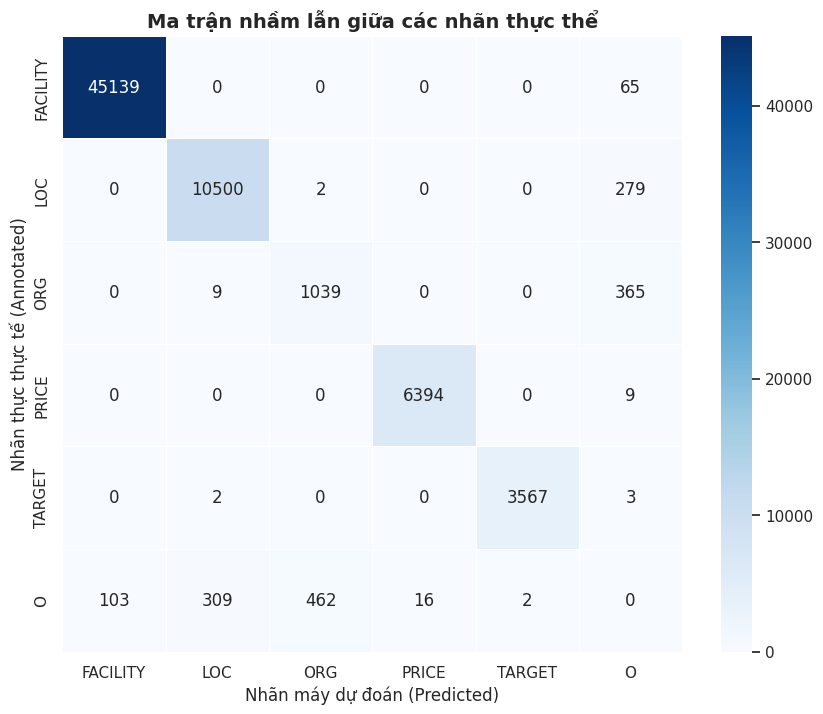

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def evaluate_for_matrix(model, test_data):
    y_true = []
    y_pred = []

    # Lấy danh sách các nhãn thực tế từ model (trừ nhãn O)
    labels = list(model.get_pipe("ner").labels)

    for text, annot in test_data:
        doc = model(text)
        gold_entities = annot['entities']
        pred_entities = [(ent.start_char, ent.end_char, ent.label_) for ent in doc.ents]

        # Tạo tập hợp để so sánh
        gold_set = {(s, e): l for s, e, l in gold_entities}
        pred_set = {(s, e): l for s, e, l in pred_entities}

        # Tìm tất cả các tọa độ xuất hiện trong cả 2 hoặc 1 trong 2
        all_coords = set(gold_set.keys()) | set(pred_set.keys())

        for coord in all_coords:
            label_true = gold_set.get(coord, "O") # Nếu không có trong gold thì là O (Máy đoán thừa)
            label_pred = pred_set.get(coord, "O") # Nếu không có trong pred thì là O (Máy bỏ sót)

            y_true.append(label_true)
            y_pred.append(label_pred)

    return y_true, y_pred, labels

# 1. Lấy dữ liệu nhãn từ bộ Test
y_true, y_pred, target_labels = evaluate_for_matrix(nlp, TEST_DATA)

# 2. Thêm nhãn 'O' vào danh sách nhãn để vẽ ma trận hoàn chỉnh
all_labels = target_labels + ['O']

# 3. Tạo Ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred, labels=all_labels)
df_cm = pd.DataFrame(cm, index=all_labels, columns=all_labels)

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', linewidths=.5)

plt.title('Ma trận nhầm lẫn giữa các nhãn thực thể', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn máy dự đoán (Predicted)', fontsize=12)
plt.ylabel('Nhãn thực thực tế (Annotated)', fontsize=12)

# Lưu ảnh
plt.savefig('/content/drive/MyDrive/Thesis_Vankhanh/Code/confusion_matrix_final.png', dpi=300)
plt.show()

In [ ]:
import spacy
from spacy import displacy

# Load model spaCy của Khanh
nlp = spacy.load('/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4')

fn_org_examples = [] # False Negatives: Gốc là ORG nhưng máy không đoán ra (nhầm thành O)
fp_org_examples = [] # False Positives: Gốc là O nhưng máy lại đoán là ORG

for text, annotations in TEST_DATA:
    doc = nlp(text)

    # Lấy tập hợp các thực thể máy đoán
    pred_ents = {(ent.start_char, ent.end_char): ent.label_ for ent in doc.ents}

    # Lấy tập hợp các thực thể nhãn gốc
    gold_ents = {(start, end): label for start, end, label in annotations['entities']}

    # 1. Tìm lỗi BỎ SÓT (Gốc có ORG, máy không đoán gì hoặc đoán nhãn khác)
    for (s, e), label in gold_ents.items():
        if label == "ORG" and (s, e) not in pred_ents:
            fn_org_examples.append((text, gold_ents, "Bỏ sót ORG"))

    # 2. Tìm lỗi ĐOÁN NHẦM (Máy đoán ORG, nhưng gốc không phải ORG)
    for (s, e), label in pred_ents.items():
        if label == "ORG" and gold_ents.get((s, e)) != "ORG":
            fp_org_examples.append((text, gold_ents, "Đoán nhầm thành ORG"))

# --- HIỂN THỊ TRỰC QUAN ĐỂ ĐƯA VÀO BÁO CÁO ---

def render_error(examples, title, limit=10):
    print(f"\n{'='*30} {title} {'='*30}")
    for i in range(min(limit, len(examples))):
        text, gold_ents, error_type = examples[i]

        # Tạo format cho displacy manual
        formatted_gold = [{'start': s, 'end': e, 'label': l} for (s, e), l in gold_ents.items()]

        print(f"\nVí dụ {i+1}:")
        print("[NHÃN GỐC]")
        displacy.render({'text': text, 'ents': formatted_gold}, style='ent', manual=True, jupyter=True)

        print("[MÁY DỰ ĐOÁN]")
        displacy.render(nlp(text), style='ent', jupyter=True)
        print("-" * 80)

# Chạy hiển thị
render_error(fn_org_examples, "TRƯỜNG HỢP BỎ SÓT ORG (NHẦM THÀNH O)")
render_error(fp_org_examples, "TRƯỜNG HỢP NHẬN DIỆN NHẦM THÀNH ORG")


============================== TRƯỜNG HỢP BỎ SÓT ORG (NHẦM THÀNH O) ==============================

Ví dụ 1:
[NHÃN GỐC]


[MÁY DỰ ĐOÁN]


--------------------------------------------------------------------------------

Ví dụ 2:
[NHÃN GỐC]


[MÁY DỰ ĐOÁN]


--------------------------------------------------------------------------------

Ví dụ 3:
[NHÃN GỐC]


...

--------------------------------------------------------------------------------

Ví dụ 9:
[NHÃN GỐC]


[MÁY DỰ ĐOÁN]


--------------------------------------------------------------------------------

Ví dụ 10:
[NHÃN GỐC]


[MÁY DỰ ĐOÁN]


--------------------------------------------------------------------------------


In [ ]:
from spacy.training.example import Example
import spacy

# Load model
path = '/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4'
nlp = spacy.load(path)

def evaluate_per_label(model, test_data):
    # Dictionary lưu trữ tp, fp, fn cho từng nhãn
    # Cấu trúc: { "LABEL_NAME": {"tp": 0, "fp": 0, "fn": 0} }
    stats = {}

    for text, annot in test_data:
        gold_entities = annot['entities']
        doc = model(text)

        # Lấy tập hợp thực thể từ dữ liệu chuẩn (gold) và máy dự đoán (pred)
        # Format: (văn bản, nhãn)
        gold_set = set([(text[s:e].strip().lower(), label) for s, e, label in gold_entities])
        pred_set = set([(ent.text.strip().lower(), ent.label_) for ent in doc.ents])

        # Cập nhật danh sách các nhãn xuất hiện trong dữ liệu
        all_labels = {label for _, label in gold_set} | {label for _, label in pred_set}
        for label in all_labels:
            if label not in stats:
                stats[label] = {"tp": 0, "fp": 0, "fn": 0}

        # Tính TP và FP
        for pred in pred_set:
            p_text, p_label = pred
            if pred in gold_set:
                stats[p_label]["tp"] += 1
            else:
                stats[p_label]["fp"] += 1

        # Tính FN
        for gold in gold_set:
            g_text, g_label = gold
            if gold not in pred_set:
                stats[g_label]["fn"] += 1

    # Tính toán chỉ số cho từng nhãn
    results = {}
    for label, count in stats.items():
        tp = count["tp"]
        fp = count["fp"]
        fn = count["fn"]

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        results[label] = {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": tp + fn # Tổng số lượng nhãn thực tế có trong data
        }

    return results

# Giả sử TEST_DATA đã được định nghĩa
results = evaluate_per_label(nlp, TEST_DATA)

print(f"{'Label':<20} | {'Precision':<10} | {'Recall':<10} | {'F1-score':<10} | {'Support':<10}")
print("-" * 65)

total_tp, total_fp, total_fn = 0, 0, 0

for label, metrics in results.items():
    print(f"{label:<20} | {metrics['precision']:<10.2f} | {metrics['recall']:<10.2f} | {metrics['f1']:<10.2f} | {metrics['support']:<10}")

# Tính toán Micro-Average (Trung bình cộng toàn bộ hệ thống)
for label in results:
    # Lấy lại tp, fp, fn từ stats nếu cần tính tổng quát,
    # hoặc tính nhanh dựa trên kết quả cuối
    pass # (Đoạn này có thể thêm để tính Overall F1 tương tự code cũ của bạn)

Label                | Precision  | Recall     | F1-score   | Support   
-----------------------------------------------------------------
FACILITY             | 1.00       | 1.00       | 1.00       | 35248     
LOC                  | 0.97       | 0.98       | 0.97       | 8926      
PRICE                | 1.00       | 1.00       | 1.00       | 5869      
TARGET               | 1.00       | 1.00       | 1.00       | 3018      
ORG                  | 0.70       | 0.74       | 0.72       | 1137      


In [ ]:
for i in range(5):
    print(TEST_DATA[i])

##**B. Gắn quan hệ**

In [ ]:

import spacy
import pandas as pd
from spacy.matcher import DependencyMatcher

# --- BƯỚC 1: LOAD MODEL VÀ DATA ---
nlp = spacy.load('/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4')

# Kiểm tra nếu chưa có sentencizer thì thêm vào
if "sentencizer" not in nlp_test.pipe_names:
    nlp_test.add_pipe("sentencizer")


def load_keywords(file_name):
    try:
        with open(file_name, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        return [x.strip() for x in lines if x.strip()]
    except FileNotFoundError:
        print(f"Không tìm thấy file {file_name}")
        return []

# Nạp dữ liệu
word_list_fac_rel = load_keywords('/content/drive/MyDrive/Thesis_Vankhanh/Code/Vocab/facility_relation.txt')
word_list_loc_rel = load_keywords('/content/drive/MyDrive/Thesis_Vankhanh/Code/Vocab/located_relation.txt')
word_list_near_rel = load_keywords('/content/drive/MyDrive/Thesis_Vankhanh/Code/Vocab/nearby_relation.txt')
word_list_suit_rel = load_keywords('/content/drive/MyDrive/Thesis_Vankhanh/Code/Vocab/suitable_relation.txt')

relation_map = {
    'HAS_FACILITY': word_list_fac_rel,
    'LOCATED_IN': word_list_loc_rel,
    'NEARBY': word_list_near_rel,
    'SUITABLE_FOR': word_list_suit_rel
}
# Hàm lọc trùng và giữ nguyên thứ tự (Ordered Set)
def ordered_set(in_list):
    out_list = []
    added = set()
    for val in in_list:
        if not val in added:
            out_list.append(val)
            added.add(val)
    return out_list

# --- PHẦN 2: XỬ LÝ CỤM TỪ ĐA TỪ (MW_LIST) ---
all_keywords_rel = word_list_fac_rel + word_list_loc_rel + word_list_near_rel + word_list_suit_rel
mw_rel_list = []

for x in all_keywords_rel:
    ws = x.split()
    if len(ws) > 1:
        # Chuyển thành tuple để spaCy hiểu đây là cụm từ cố định
        mw_rel_list.append(tuple(ws))

mw_rel_list = ordered_set(mw_rel_list)

print(f"Đã chuẩn bị xong mw_list với {len(mw_rel_list)} cụm từ.")
print("Ví dụ 5 cụm đầu tiên:", mw_rel_list[0:10])



Đã chuẩn bị xong mw_list với 241 cụm từ.
Ví dụ 5 cụm đầu tiên: [('within', 'the', 'hotel'), ('is', 'equipped', 'with'), ('comes', 'with'), ('equipped', 'with'), ('stay', 'at'), ('Staying', 'at'), ('Located', 'in'), ('located', 'in'), ('close', 'to'), ('within', 'close')]


### Check evaluate quan hệ

In [ ]:
import pandas as pd
from google.colab import files # Thư viện để tải file về máy

# 1. Kiểm tra và lấy mẫu ngẫu nhiên
if not df_final_relations_depen1.empty:
    num_samples = min(500, len(df_final_relations_depen1))
    # Lấy mẫu ngẫu nhiên 500 dòng
    df_manual_check = df_final_relations_depen1.sample(n=num_samples, random_state=42)

    # 2. Lọc các cột cần thiết
    column_outputs = ['Hotel_Name', 'Relation', 'Object', 'Object_Type', 'Context']
    df_manual_check = df_manual_check[[col for col in column_outputs if col in df_manual_check.columns]]

    # 3. Thêm cột để Khanh chấm điểm (Y là đúng, N là sai)
    df_manual_check['Is_Correct_Y_N'] = ""
    df_manual_check['Error_Type'] = "" # Để ghi chú loại lỗi nếu có

    # 4. Lưu file Excel
    file_name = "Manual_Check_Relations_500.xlsx"
    df_manual_check.to_excel(file_name, index=False)

    print(f"--- Đã tạo xong file: {file_name} ---")

    # 5. Lệnh tải file về máy tính
    files.download(file_name)

else:
    print("Không có dữ liệu để xuất.")

--- Đã tạo xong file: Manual_Check_Relations_500.xlsx ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files
import spacy

# Load sentencizer nếu chưa có
if "sentencizer" not in nlp.pipe_names:
    nlp.add_pipe("sentencizer")

def get_short_context(full_text, obj_text):
    """Hàm bổ trợ để lấy đúng câu chứa thực thể, giúp file Excel gọn nhẹ"""
    doc = nlp(full_text)
    for sent in doc.sents:
        if obj_text in sent.text:
            return sent.text.strip()
    return full_text[:200] # Nếu không tìm thấy thì cắt 200 ký tự đầu

if not df_final_relations_depen1.empty:
    # 1. Lấy mẫu ngẫu nhiên 500 dòng
    num_samples = min(500, len(df_final_relations_depen1))
    df_manual_check = df_final_relations_depen1.sample(n=num_samples, random_state=42).copy()

    # 2. Rút gọn Context: Chỉ lấy câu chứa Object để dễ đọc
    print("Đang tối ưu hóa Context để dễ đọc hơn...")
    df_manual_check['Short_Context'] = df_manual_check.apply(
        lambda x: get_short_context(x['Context'], x['Object']), axis=1
    )

    # 3. Sắp xếp cột cho khoa học: Hotel -> Relation -> Object -> Short Context
    column_outputs = ['Hotel_Name', 'Relation', 'Object', 'Object_Type', 'Short_Context', 'Context']
    df_manual_check = df_manual_check[column_outputs]

    # 4. Thêm cột chấm điểm
    df_manual_check['Is_Correct (Y/N)'] = ""
    df_manual_check['Error_Reason'] = ""

    # 5. Xuất file và tải về
    file_name = "Kiem_tra_Quan_he_Rut_gon.xlsx"
    df_manual_check.to_excel(file_name, index=False)

    print(f"--- Đã tối ưu hóa xong! ---")
    files.download(file_name)
else:
    print("Không có dữ liệu.")

Đang tối ưu hóa Context để dễ đọc hơn...
--- Đã tối ưu hóa xong! ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files
import spacy

# Đảm bảo nlp đã được load (sm cho nhẹ hoặc model của bạn)
if 'nlp' not in locals():
    nlp = spacy.load("en_core_web_sm")

if "sentencizer" not in nlp.pipe_names:
    nlp.add_pipe("sentencizer")

def get_only_relevant_sentence(full_text, obj_text):
    """Chỉ trả về câu chứa thực thể, nếu không có trả về None"""
    doc = nlp(str(full_text))
    for sent in doc.sents:
        if str(obj_text).lower() in sent.text.lower():
            return sent.text.strip()
    return None

if not df_final_relations_depen1.empty:
    # 1. Tạo cột câu bằng chứng trước
    print("Đang quét và tách câu chứa thực thể...")
    df_temp = df_final_relations_depen1.copy()
    df_temp['Evidence_Sentence'] = df_temp.apply(
        lambda x: get_only_relevant_sentence(x['Context'], x['Object']), axis=1
    )

    # 2. CHỈ LẤY những dòng có câu chứa thực thể (loại bỏ None)
    df_filtered = df_temp[df_temp['Evidence_Sentence'].notna()].copy()

    print(f"Tìm thấy {len(df_filtered)} quan hệ có câu bằng chứng rõ ràng.")

    # 3. Lấy mẫu ngẫu nhiên 500 dòng từ tập đã lọc
    num_samples = min(500, len(df_filtered))
    df_manual_check = df_filtered.sample(n=num_samples, random_state=42)

    # 4. Sắp xếp cột cho gọn để chấm bài
    # Mình bỏ cột Context gốc đi cho file nhẹ, chỉ giữ Evidence_Sentence
    column_outputs = ['Hotel_Name', 'Relation', 'Object', 'Object_Type', 'Evidence_Sentence']
    df_manual_check = df_manual_check[column_outputs]

    # 5. Thêm cột để bạn và LLM chấm điểm
    df_manual_check['Is_Correct (Y/N)'] = ""
    df_manual_check['Error_Reason'] = ""

    # 6. Xuất file và tải về
    file_name = "File_Check_Manual_Rut_Gon_Triet_De.xlsx"
    df_manual_check.to_excel(file_name, index=False)

    print(f"--- Đã xong! File {file_name} đã sẵn sàng để tải về ---")
    files.download(file_name)
else:
    print("Không có dữ liệu để xử lý.")

Đang quét và tách câu chứa thực thể...
Tìm thấy 27030 quan hệ có câu bằng chứng rõ ràng.
--- Đã xong! File File_Check_Manual_Rut_Gon_Triet_De.xlsx đã sẵn sàng để tải về ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files


df_eval = df_final_relations_1.sample(n=500, random_state=1)
df_eval.to_excel('df_eval.xlsx', index=False)

files.download('df_eval.xlsx')

In [ ]:
import pandas as pd

file_path1 = '/content/drive/MyDrive/Thesis_Vankhanh/Code/Rel_check.xlsx'
df_reviews = pd.read_excel(file_path1)



# 2. Tính Accuracy (Độ chính xác tổng quát)
# Giả sử Is_Correct = 1 là đúng, 0 là sai
tp = df_reviews['Is_Correct'].sum()
total = len(df_reviews)
accuracy = tp / total

# 3. Phân tích lỗi (Thống kê Error_Type)

print(f"--- KẾT QUẢ ĐÁNH GIÁ RELATION EXTRACTION ---")
print(f"Tổng số mẫu kiểm tra: {total}")
print(f"Số quan hệ đúng (TP): {tp}")
print(f"Accuracy: {accuracy*100:.2f}%")
print("-" * 40)


In [ ]:
import pandas as pd

# 1. Nạp dữ liệu
file_path1 = '/content/drive/MyDrive/Thesis_Vankhanh/Code/MANUAL_CHECK.xlsx'
df_reviews = pd.read_excel(file_path1)

# 2. Tính toán tổng quát
total = len(df_reviews)
tp = df_reviews['Is_Correct_Y_N'].sum()
overall_precision = tp / total

# 3. Đánh giá chi tiết theo từng nhãn (Relation Type)
# Giả sử cột chứa tên quan hệ của Khanh tên là 'Relation'
relation_stats = df_reviews.groupby('Relation').agg(
    Total_Samples=('Is_Correct_Y_N', 'count'),
    Correct_Samples=('Is_Correct_Y_N', 'sum')
).reset_index()

# Tính Precision cho từng nhãn
relation_stats['Precision (%)'] = (relation_stats['Correct_Samples'] / relation_stats['Total_Samples'] * 100).round(2)

# 4. In kết quả
print(f"--- KẾT QUẢ ĐÁNH GIÁ RELATION EXTRACTION ---")
print(f"Tổng số mẫu kiểm tra: {total}")
print(f"Độ chính xác trung bình (Overall Precision): {overall_precision*100:.2f}%")
print("\n--- CHI TIẾT THEO TỪNG NHÃN QUAN HỆ ---")
print(relation_stats.to_string(index=False))

print("-" * 40)

# 5. Phân tích lỗi (Error Type) nếu có cột Error_Type
if 'Error_Type' in df_reviews.columns:
    print("\n--- PHÂN TÍCH CÁC LOẠI LỖI PHỔ BIẾN ---")
    error_counts = df_reviews[df_reviews['Is_Correct_Y_N'] == 0]['Error_Type'].value_counts()
    print(error_counts)

--- KẾT QUẢ ĐÁNH GIÁ RELATION EXTRACTION ---
Tổng số mẫu kiểm tra: 500
Độ chính xác trung bình (Overall Precision): 83.20%

--- CHI TIẾT THEO TỪNG NHÃN QUAN HỆ ---
      Relation  Total_Samples  Correct_Samples  Precision (%)
  HAS_FACILITY            273              256          93.77
HAS_PRICE_INFO             75               59          78.67
    LOCATED_IN             67               46          68.66
        NEARBY             65               36          55.38
  SUITABLE_FOR             20               19          95.00
----------------------------------------

--- PHÂN TÍCH CÁC LOẠI LỖI PHỔ BIẾN ---
Series([], Name: count, dtype: int64)


In [ ]:
def extract_relations_flexible_v2(data_list, window_size=500):
    results = []

    for text in data_list:
        doc = nlp_test(text)
        last_hotel = None  # Biến này để ghi nhớ khách sạn gần nhất

        for sent in doc.sents:
            sent_text_low = sent.text.lower() # Để check keyword nearby
            entities = sent.ents
            hotels = [ent for ent in entities if ent.label_ == "ORG"]
            others = [ent for ent in entities if ent.label_ != "ORG"]

            # Nếu trong câu có tên khách sạn mới, cập nhật last_hotel
            if hotels:
                last_hotel = hotels[0].text

            # Nếu đã từng thấy khách sạn (trong câu này hoặc câu trước)
            if last_hotel:
                for other in others:
                    found_rel = None

                    if other.label_ == "FACILITY":
                        found_rel = "HAS_FACILITY"

                    # 2. LOC: Check vocab NEARBY trước, không có thì mặc định LOCATED_IN
                    elif other.label_ == "LOC":
                        if any(w in sent_text_low for w in word_list_near_rel):
                            found_rel = "NEARBY"
                        else:
                            found_rel = "LOCATED_IN"

                    # 3. TARGET mặc định là SUITABLE_FOR
                    elif other.label_ == "TARGET":
                        found_rel = "SUITABLE_FOR"

                    if found_rel:
                        results.append({
                            "Hotel_Name": last_hotel,
                            "Relation": found_rel,
                            "Object": other.text,
                            "Object_Type": other.label_,
                            "Context": sent.text
                        })

    return pd.DataFrame(results).drop_duplicates()

### PP 1 (theo từ vựng)

In [ ]:
def check_and_extract(data_list, window_size=50):
    all_results = []

    for idx, text in enumerate(data_list):
        doc = nlp_test(text)
        entities = doc.ents

        hotels = [ent for ent in entities if ent.label_ == "ORG"]
        others = [ent for ent in entities if ent.label_ != "ORG"]

        if not hotels:
            continue

        # print(f"--- Đang xử lý câu {idx} ---") # Bỏ bớt log cho sạch nếu chạy data lớn

        for hotel in hotels:
            for other in others:
                start_char = min(hotel.end_char, other.end_char)
                end_char = max(hotel.start_char, other.start_char)
                gap_text = text[start_char:end_char].lower()

                # Check khoảng cách từ
                gap_words = gap_text.split()
                if len(gap_words) > window_size:
                    continue

                found_rel = None

                # --- LOGIC MAPPING ---

                # 1. PRICE (Ưu tiên xử lý vì không cần vocab)
                if other.label_ == "PRICE":
                    found_rel = "HAS_PRICE_INFO"

                # 2. FACILITY
                elif other.label_ == "FACILITY":
                    if any(w.lower() in gap_text for w in word_list_fac_rel):
                        found_rel = "HAS_FACILITY"

                # 3. LOC (Phân tách NEARBY và LOCATED_IN)
                elif other.label_ == "LOC":
                    # Ưu tiên kiểm tra từ khóa "gần" trước
                    if any(w.lower() in gap_text for w in word_list_near_rel):
                        found_rel = "NEARBY"
                    # Nếu không có từ khóa "gần" thì mới check từ khóa "tọa lạc"
                    elif any(w.lower() in gap_text for w in word_list_loc_rel):
                        found_rel = "LOCATED_IN"

                # 4. TARGET
                elif other.label_ == "TARGET":
                    if any(w.lower() in gap_text for w in word_list_suit_rel):
                        found_rel = "SUITABLE_FOR"

                # Ghi nhận kết quả
                if found_rel:
                    # print(f"Bắt được: {hotel.text} --[{found_rel}]--> {other.text}")
                    all_results.append({
                        "Hotel_Name": hotel.text,
                        "Relation": found_rel,
                        "Object": other.text,
                        "Object_Type": other.label_,
                        "Gap_Words": len(gap_words),
                        "Context": text
                    })

    return pd.DataFrame(all_results).drop_duplicates()

In [ ]:
import pandas as pd
import re

def check_and_extract(data_list, window_size=50):
    all_results = []

    # ==========================================
    # TỪ ĐIỂN THÉP (ÉP KIỂU QUAN HỆ & BỘ LỌC RÁC)
    # ==========================================
    junk_hotel_names = ['vo dinh thuy trang', 'mr.', 'ms.']

    admin_keywords = ['vietnam', 'nha trang', 'da lat', 'dalat', 'da nang', 'danang', 'phu quoc',
                      'vung tau', 'hanoi', 'sapa', 'hcm', 'hcmc', 'cam ranh', 'ninh hoa',
                      'district', 'ward', 'province', 'city', 'street', 'old quarter']

    landmark_keywords = ['mart', 'lotte', 'vin', 'wonders', 'safari', 'grand world', 'crazy house',
                         'palace', 'bridge', 'beach', 'lake', 'river', 'market', 'mall', 'plaza', 'fishing village',
                         'airport', 'tower', 'square', 'secc', 'new world', 'opera house', 'local shops',
                         'island', 'beachfront', 'shore', 'cable car', 'station', 'big c', 'circle k', 'cu chi tunnel']

    junk_words = ['lush', 'a 3','to 3' ,'to 1', 'to 6', 'to 4', 'to 2', 'to 8','to 7',
                  'eco', 'apple', 'anh', 'phuc', 'clouds', '????']

    force_facility_keywords = ['fish pond', 'motorbike pa', 'parking', 'pool', 'gym', 'spa']

    for idx, text in enumerate(data_list):
        doc = nlp_test(text)
        entities = doc.ents

        hotels = [ent for ent in entities if ent.label_ == "ORG" and ent.text.lower().strip() not in junk_hotel_names]
        others = [ent for ent in entities if ent.label_ != "ORG"]

        if not hotels:
            continue

        for hotel in hotels:
            for other in others:
                obj_text_lower = other.text.lower().strip()

                # --- BƯỚC 1: LỌC RÁC ---
                if not re.search(r'[a-zA-Z0-9]', obj_text_lower):
                    continue

                if any(junk == obj_text_lower for junk in junk_words) or len(obj_text_lower) <= 2:
                    continue

                # --- BƯỚC 1.5: ÉP KIỂU NHÃN ---
                if any(kw in obj_text_lower for kw in force_facility_keywords):
                    current_label = "FACILITY"
                else:
                    current_label = other.label_

                start_char = min(hotel.end_char, other.end_char)
                end_char = max(hotel.start_char, other.start_char)
                gap_text = text[start_char:end_char].lower()

                gap_words = gap_text.split()
                if len(gap_words) > window_size:
                    continue

                found_rel = None

                # --- BƯỚC 2: LOGIC MAPPING CẢI TIẾN ---
                if current_label == "PRICE":
                    found_rel = "HAS_PRICE_INFO"

                elif current_label == "FACILITY":
                    negation_words = ["no", "not", "without", "lack", "doesn't", "don't", "didn't"]
                    if not any(neg in gap_text for neg in negation_words):
                        if any(w.lower() in gap_text for w in word_list_fac_rel):
                            found_rel = "HAS_FACILITY"

                elif current_label == "LOC":
                    is_admin = any(kw in obj_text_lower for kw in admin_keywords)
                    is_landmark = any(kw in obj_text_lower for kw in landmark_keywords)

                    if is_landmark and not is_admin:
                        found_rel = "NEARBY"
                    elif is_admin and not is_landmark:
                        found_rel = "LOCATED_IN"
                    else:
                        if any(w.lower() in gap_text for w in word_list_near_rel):
                            found_rel = "NEARBY"
                        elif any(w.lower() in gap_text for w in word_list_loc_rel):
                            found_rel = "NEARBY" if is_landmark else "LOCATED_IN"

                elif current_label == "TARGET":
                    if any(w.lower() in gap_text for w in word_list_suit_rel):
                        found_rel = "SUITABLE_FOR"

                # Ghi nhận kết quả
                if found_rel:
                    # --- MỚI THÊM: CẮT CÂU (TARGET SENTENCE) CHỨA CẢ 2 THỰC THỂ ---
                    # Lấy vị trí bắt đầu của câu chứa thực thể đầu tiên
                    sent_start = min(hotel.sent.start_char, other.sent.start_char)
                    # Lấy vị trí kết thúc của câu chứa thực thể cuối cùng
                    sent_end = max(hotel.sent.end_char, other.sent.end_char)

                    target_sentence = text[sent_start:sent_end].strip()

                    all_results.append({
                        "Hotel_Name": hotel.text,
                        "Relation": found_rel,
                        "Object": other.text,
                        "Object_Type": current_label,
                        "Target_Sentence": target_sentence, # Thêm cột Target_Sentence xịn xò
                        "Context": text,
                        "_gap_len": len(gap_words) # Biến tạm để lát nữa sort
                    })

    # Convert sang DataFrame
    df_result = pd.DataFrame(all_results)

    # Nếu bảng trống thì trả về luôn
    if df_result.empty:
        return df_result

    # Sắp xếp theo _gap_len để giữ lại quan hệ gần nhất, loại bỏ trùng lặp
    df_result = df_result.sort_values('_gap_len').drop_duplicates(subset=['Hotel_Name', 'Relation', 'Object'], keep='first')

    # XÓA CỘT BẢN NHÁP _gap_len ra khỏi file cuối cùng
    df_result = df_result.drop(columns=['_gap_len'])

    return df_result

In [ ]:
import pandas as pd
import spacy

# Load df_reviews
file_path = '/content/drive/MyDrive/Thesis_Vankhanh/Code/Agoda_Reviews_cleaned_v3.xlsx'
df_reviews = pd.read_excel(file_path)

# Load nlp_test model
model_path = "/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4"
nlp_test = spacy.load(model_path)

# Add sentencizer BEFORE calling check_and_extract
if "sentencizer" not in nlp_test.pipe_names:
    nlp_test.add_pipe("sentencizer")

reviews_depen1 = df_reviews['clean_comments'].fillna("").tolist()

df_final_relations_depen1 = check_and_extract(reviews_depen1, window_size=500)

# 3. Hiển thị và Thống kê
if df_final_relations_depen1.empty:
    print("No relation")
else:
    print(f"{len(df_final_relations_depen1)} relations")

    print("loại Relation:")
    stats = df_final_relations_depen1['Relation'].value_counts()
    print(stats)

    print(f"\nSố lượng khách sạn duy nhất: {df_final_relations_depen1['Hotel_Name'].nunique()}")

    display(df_final_relations_depen1.head(10))

10039 relations
loại Relation:
Relation
HAS_FACILITY      3082
LOCATED_IN        2347
HAS_PRICE_INFO    2182
NEARBY            1887
SUITABLE_FOR       541
Name: count, dtype: int64

Số lượng khách sạn duy nhất: 1298


,Hotel_Name,Relation,Object,Object_Type,Target_Sentence,Context
5042,King,NEARBY,Market,LOC,If you go straight left out of the hotel for a...,"The room has been cramped for too long , and t..."
5034,Long,NEARBY,Beach,LOC,The location is great Close to Long Beach .,The staff members are very friendly . The loca...
20077,Beach Hotel,LOCATED_IN,Da Nang,LOC,We recently spent 7 nights with Serene Beach H...,We recently spent 7 nights with Serene Beach H...
5006,Sailing,NEARBY,Beach,LOC,The accommodation offers free car arrangements...,"The villa is very large , clean , and comforta..."
8261,Trang Trang Premium Hotel,LOCATED_IN,Hanoi,LOC,We had a wonderful stay at Trang Trang Premium...,We had a wonderful stay at Trang Trang Premium...
20333,Son Tra Resort Spa,LOCATED_IN,Da Nang,LOC,"When visiting Da Nang , everyone should consid...",I went to Da Nang during the cold spell I hear...
20366,Prague Hotel,LOCATED_IN,Da Nang,LOC,I had a pleasant stay at Prague Hotel Da Nang .,I had a pleasant stay at Prague Hotel Da Nang ...
7986,Golden,NEARBY,Lake,LOC,I had a wonderful stay at Dolce by Wyndham Han...,I had a wonderful stay at Dolce by Wyndham Han...
7985,Golden,LOCATED_IN,Hanoi,LOC,I had a wonderful stay at Dolce by Wyndham Han...,I had a wonderful stay at Dolce by Wyndham Han...
7984,West,NEARBY,Lake,LOC,This was the most touching point It has been a...,This place is filled with advantages . . Havin...


In [ ]:
from google.colab import files

# Tên file bạn muốn đặt
file_name = "df_final_relations_depen.csv"

# Chuyển DataFrame thành CSV (dùng utf-8-sig để không lỗi font tiếng Việt khi mở bằng Excel)
df_final_relations_depen1.to_csv(file_name, index=False, encoding='utf-8-sig')

# Lệnh tải về máy
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files

# 1. Lọc lấy 3 quan hệ cốt lõi
target_relations = ['HAS_FACILITY', 'HAS_PRICE_INFO']
df_target = df_final_relations_depen1[df_final_relations_depen1['Relation'].isin(target_relations)]

# 2. THUẬT TOÁN BỐC MẪU CÂN BẰNG (Balanced Sampling)
# Mục tiêu: Lấy 600 câu, chia đều 3 nhóm -> Mỗi nhóm tiêu chuẩn là 200 câu
n_per_group = 200

# Bước 2.1: Rút mỗi nhóm tối đa 200 câu (Nhóm nào ít hơn 200 thì lấy hết sạch)
df_sample = df_target.groupby('Relation', group_keys=False).apply(lambda x: x.sample(min(len(x), n_per_group), random_state=42))

# Bước 2.2: Bù đắp phần thiếu (Nếu có nhóm bị thiếu, ta lấy thêm Facility để bù cho đủ 600)
so_cau_con_thieu = 200 - len(df_sample)
if so_cau_con_thieu > 0:
    # Tìm những câu chưa được bốc
    df_unused = df_target.drop(df_sample.index)
    # Bốc thêm phần thiếu
    df_padding = df_unused.sample(min(len(df_unused), so_cau_con_thieu), random_state=42)
    # Gộp lại
    df_sample = pd.concat([df_sample, df_padding])

# Trộn đều lên một lần nữa (Shuffle) cho mượt
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Tạo cột Sentiment và Xuất file như cũ
df_sample['Sentiment'] = ""
desired_columns = ['Context', 'Hotel_Name', 'Object', 'Relation', 'Sentiment']
final_columns = [col for col in desired_columns if col in df_sample.columns]
df_export = df_sample[final_columns]

export_filename = 'Sentiment_Manual_Labeling.xlsx'
df_export.to_excel(export_filename, index=False)
files.download(export_filename)

# In ra báo cáo xem nó bốc được bao nhiêu câu mỗi loại:
print("📊 BÁO CÁO SỐ LƯỢNG MẪU ĐƯỢC CHỌN:")
print(df_sample['Relation'].value_counts())
print(f"✅ TỔNG CỘNG: {len(df_sample)} câu đã sẵn sàng!")

/tmp/ipykernel_5988/1640509322.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_target.groupby('Relation', group_keys=False).apply(lambda x: x.sample(min(len(x), n_per_group), random_state=42))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📊 BÁO CÁO SỐ LƯỢNG MẪU ĐƯỢC CHỌN:
Relation
HAS_PRICE_INFO    200
HAS_FACILITY      200
Name: count, dtype: int64
✅ TỔNG CỘNG: 400 câu đã sẵn sàng!


#### Bo sung mau Neg/Neu

In [ ]:
import pandas as pd
import re
from google.colab import files

# ==========================================
# BƯỚC 0: TỰ ĐỘNG TẠO CỘT TARGET_SENTENCE TỪ CONTEXT
# ==========================================
def extract_target_sentence(context, obj):
    """Hàm tìm câu chứa Object trong đoạn văn dài"""
    if pd.isna(context) or pd.isna(obj):
        return context

    # Tách đoạn văn thành các câu (dựa trên dấu chấm, chấm than, hỏi chấm hoặc xuống dòng)
    sentences = re.split(r'(?<=[.!?\n])\s+', str(context))

    # Tìm câu chứa Object (không phân biệt hoa thường)
    for sentence in sentences:
        if str(obj).lower() in sentence.lower():
            return sentence.strip()

    return context # Nếu không tìm thấy, trả về nguyên đoạn văn

print("⚙️ Đang tự động trích xuất Target_Sentence từ Context...")
# df_final_relations_depen1 là data gốc của ông
df_new_pool = df_final_relations_depen1.copy()
df_new_pool['Target_Sentence'] = df_new_pool.apply(lambda row: extract_target_sentence(row['Context'], row['Object']), axis=1)


# ==========================================
# BƯỚC 1: ĐỌC DATA CŨ VÀ LỌC BỎ CÂU ĐÃ DÁN NHÃN
# ==========================================
print("📂 Đang kiểm tra dữ liệu cũ...")
try:
    # Đọc file cũ ông đã làm theo đúng đường dẫn Drive của ông
    file_path = '/content/drive/MyDrive/Thesis_Vankhanh/Code/Manual_sentiment.xlsx'
    df_old  = pd.read_excel(file_path)
    # Tạo chìa khóa ghép (Câu review + Khía cạnh) để đảm bảo độ unique
    old_keys = df_old['Context'].astype(str) + "||" + df_old['Object'].astype(str)
    print(f"Đã tìm thấy {len(df_old)} câu trong tập dữ liệu cũ.")
except FileNotFoundError:
    print("⚠️ Không tìm thấy file Manual_sentiment.xlsx. Sẽ bốc mẫu trên toàn bộ data gốc.")
    old_keys = pd.Series(dtype=str)

df_new_pool['Unique_Key'] = df_new_pool['Context'].astype(str) + "||" + df_new_pool['Object'].astype(str)

# Lọc: Chỉ giữ lại những câu MỚI TOANH (Unique_Key KHÔNG NẰM TRONG old_keys)
df_unseen = df_new_pool[~df_new_pool['Unique_Key'].isin(old_keys)].copy()
print(f"Kho dữ liệu Unseen (Mới 100%) còn lại: {len(df_unseen)} câu.")


# ==========================================
# BƯỚC 2: SĂN NHÃN NEGATIVE / NEUTRAL BẰNG TỪ KHÓA (TIẾNG ANH)
# ==========================================
# Tập hợp các từ khóa thường dùng khi chê hoặc nhận xét trung tính
neg_neu_keywords = [
    'but', 'however', 'although', 'though', 'despite', 'yet', 'except', 'rather',
    'average', 'okay', 'ok', 'acceptable', 'basic', 'standard', 'fine', 'decent',
    'normal', 'adequate', 'alright', 'minimal', 'somewhat', 'fairly', 'just', 'only',
    'small', 'tiny', 'cramped', 'noisy', 'loud', 'dirty', 'dusty', 'stained', 'stains',
    'expensive', 'overpriced', 'bad', 'poor', 'terrible', 'awful', 'horrible', 'worst',
    'unacceptable', 'old', 'outdated', 'broken', 'useless', 'unhelpful', 'unfriendly',
    'rude', 'slow', 'cold', 'uncomfortable',
    'lack', 'smell', 'late', 'wait', 'issue', 'problem', 'complain', 'complaint',
    'manager', 'fix', 'maintenance', 'ignore', 'ignored', 'bug', 'bugs', 'insects',
    'charge', 'fee', 'extra', 'refund',
    'unfortunately', 'disappointed', 'disappointing', 'unhappy', 'regret', 'avoid',
    'never', 'not', 'no', 'nothing special'
]

def contains_keywords(text, keywords):
    text_lower = str(text).lower()
    # Kiểm tra xem có bất kỳ từ khóa nào xuất hiện trong câu không
    return any(kw in text_lower for kw in keywords)

# Lọc ra những câu nghi ngờ cao (QUÉT TRÊN Target_Sentence SẼ CHUẨN XÁC HƠN)
df_suspect = df_unseen[df_unseen['Target_Sentence'].apply(lambda x: contains_keywords(x, neg_neu_keywords))]
print(f"🎯 Đã 'săn' được {len(df_suspect)} câu Unseen có dấu hiệu Negative/Neutral!")


# ==========================================
# BƯỚC 3: LỌC QUAN HỆ & BỐC MẪU
# ==========================================
target_relations = ['HAS_FACILITY', 'HAS_PRICE_INFO']
df_target = df_suspect[df_suspect['Relation'].isin(target_relations)]

# Bốc 200 câu từ tập đã săn được để ông dán tay (ông có thể đổi số này)
n_sample = min(200, len(df_target))
df_sample = df_target.sample(n=n_sample, random_state=42).reset_index(drop=True)


# ==========================================
# BƯỚC 4: XUẤT FILE ĐỂ DÁN NHÃN
# ==========================================
df_sample['Sentiment'] = ""

# ĐÃ BỔ SUNG CỘT Target_Sentence ĐỂ ÔNG ĐỌC CHO TIỆN
desired_columns = ['Context', 'Target_Sentence', 'Hotel_Name', 'Object', 'Relation', 'Sentiment']

final_columns = [col for col in desired_columns if col in df_sample.columns]
df_export = df_sample[final_columns]

export_filename = 'Data_Bo_Sung_Neg_Neu.xlsx'
df_export.to_excel(export_filename, index=False)
files.download(export_filename)

print("\n📊 BÁO CÁO MẪU BỔ SUNG:")
print(df_sample['Relation'].value_counts())
print(f"✅ TỔNG CỘNG: {len(df_sample)} câu đã sẵn sàng! Mở file Data_Bo_Sung_Neg_Neu.xlsx lên chiến thôi!")

⚙️ Đang tự động trích xuất Target_Sentence từ Context...
📂 Đang kiểm tra dữ liệu cũ...
Đã tìm thấy 1000 câu trong tập dữ liệu cũ.
Kho dữ liệu Unseen (Mới 100%) còn lại: 8795 câu.
🎯 Đã 'săn' được 4504 câu Unseen có dấu hiệu Negative/Neutral!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📊 BÁO CÁO MẪU BỔ SUNG:
Relation
HAS_PRICE_INFO    101
HAS_FACILITY       99
Name: count, dtype: int64
✅ TỔNG CỘNG: 200 câu đã sẵn sàng! Mở file Data_Bo_Sung_Neg_Neu.xlsx lên chiến thôi!


### LLM modify

In [ ]:
!pip uninstall -y google-generativeai
!pip install google-genai

Found existing installation: google-generativeai 0.8.6
Uninstalling google-generativeai-0.8.6:
  Successfully uninstalled google-generativeai-0.8.6


In [ ]:
from google import genai
from google.genai import types
import json
import time
import pandas as pd
from tqdm import tqdm

# ==============================================================================
# 1. CẤU HÌNH API & THÔNG SỐ
# ==============================================================================
from google.colab import userdata
API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=API_KEY)

# Lựa chọn chế độ chạy
RUN_MODE = "TEST"
BATCH_SIZE = 20
OUTPUT_FILE = "Relation_Gold_Standard_Cleaned.csv"

# ==============================================================================
# 2. HÀM XỬ LÝ BATCH (ĐÃ CẬP NHẬT BÓC TÁCH JSON AN TOÀN)
# ==============================================================================
def validate_relations_batch(batch_data):
    input_json_str = json.dumps(batch_data, ensure_ascii=False)

    prompt = f"""
    Return a JSON object with a "results" key containing a list of objects.
    Each object must have "id" (int) and "status" (string: "VALID" or "INVALID").

    Context: Validate these hotel relationships based on the rules:
    - HAS_PRICE_INFO: Specific cost details.
    - HAS_FACILITY: Hotel provides/owns this amenity.
    - NEARBY: Close to location, but NOT inside it.
    - LOCATED_IN: Physically inside an area/city.
    - SUITABLE_FOR: Appropriate for a target audience.
    - IMPORTANT: If context shows negation (e.g. "no pool"), status is INVALID.

    DATA TO VALIDATE:
    {input_json_str}
    """

    config = types.GenerateContentConfig(
        response_mime_type="application/json",
        temperature=0.1
    )

    for attempt in range(3):
        try:
            response = client.models.generate_content(
                model='gemini-2.5-flash',  # THÊM "models/" VÀO ĐÂY
                contents=prompt,
                config=config
            )

            # Xử lý chuỗi trả về để đảm bảo là JSON thuần túy
            clean_text = response.text.strip()
            if "```json" in clean_text:
                clean_text = clean_text.split("```json")[1].split("```")[0].strip()

            result_json = json.loads(clean_text)

            # Tạo map kết quả theo ID để tránh sai thứ tự
            res_map = {int(item["id"]): item["status"] for item in result_json["results"]}

            status_list = []
            for original_item in batch_data:
                # Nếu ID không tồn tại trong kết quả, mặc định là INVALID để an toàn
                status_list.append(res_map.get(original_item["id"], "INVALID"))

            return status_list, "SUCCESS"

        except Exception as e:
            # Nếu lỗi, nghỉ lâu hơn một chút để reset API connection
            time.sleep(10)
            if attempt == 2:
                return ["ERROR"] * len(batch_data), "FAIL_API"

# ==============================================================================
# 3. CHUẨN BỊ DỮ LIỆU
# ==============================================================================
# Sử dụng df_final_relations_depen1 từ bước Rule-based của bạn
if RUN_MODE == "TEST":
    df_to_process = df_final_relations_depen1.sample(n=min(30, len(df_final_relations_depen1)), random_state=42).copy()
else:
    df_to_process = df_final_relations_depen1.copy()

df_to_process = df_to_process.reset_index(drop=True)

# ==============================================================================
# 4. CHẠY VÒNG LẶP XỬ LÝ (TĂNG THỜI GIAN NGHỈ ĐỂ TRÁNH RATE LIMIT)
# ==============================================================================
final_statuses = []
print(f"🚀 Chế độ: {RUN_MODE} | Đang xử lý {len(df_to_process)} dòng...")

for i in tqdm(range(0, len(df_to_process), BATCH_SIZE)):
    batch_df = df_to_process.iloc[i:i+BATCH_SIZE]
    batch_payload = [{"id": idx, "Context": row["Context"], "Hotel_Name": row["Hotel_Name"],
                      "Relation": row["Relation"], "Object": row["Object"]}
                     for idx, row in batch_df.iterrows()]

    batch_statuses, api_status = validate_relations_batch(batch_payload)
    final_statuses.extend(batch_statuses)

    # Nghỉ 8-10 giây mỗi lô để đảm bảo API không bị quá tải (Rate Limit)
    time.sleep(10)

# Gán lại kết quả vào Dataframe
df_to_process['LLM_Status'] = xa

# ==============================================================================
# 5. KẾT QUẢ & LƯU TRỮ
# ==============================================================================
if RUN_MODE == "TEST":
    print("\n--- 📊 KẾT QUẢ CHẠY THỬ (PREVIEW) ---")
    # Hiển thị bảng kết quả chi tiết
    display(df_to_process[['Hotel_Name', 'Relation', 'Object', 'LLM_Status', 'Context']].head(30))
else:
    # Lọc lấy tập dữ liệu sạch (Gold Standard)
    df_gold = df_to_process[df_to_process['LLM_Status'] == 'VALID'].drop(columns=['LLM_Status'])

    # Cân bằng dữ liệu để chống lệch nhãn khi train BERT
    df_balanced = df_gold.groupby('Relation').apply(
        lambda x: x.sample(n=min(len(x), 1500), random_state=42)
    ).reset_index(drop=True)

    df_balanced.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
    print(f"✅ Hoàn thành! Đã lưu tập dữ liệu cân bằng vào: {OUTPUT_FILE}")
    print(df_balanced['Relation'].value_counts())

🚀 Chế độ: TEST | Đang xử lý 30 dòng...


100%|██████████| 2/2 [01:22<00:00, 41.09s/it]


--- 📊 KẾT QUẢ CHẠY THỬ (PREVIEW) ---


,Hotel_Name,Relation,Object,LLM_Status,Context
0,Beach Hotel,HAS_FACILITY,seafront,ERROR,Im glad that I booked Platinum Beach Hotel Dan...
1,Beach Hotel,LOCATED_IN,Da Nang,ERROR,I had an absolutely fantastic stay at SANA Dan...
2,LA VELA Saigon Hotel,HAS_FACILITY,attractions,ERROR,I had a fantastic stay at LA VELA Saigon Hotel...
3,West,HAS_FACILITY,room,ERROR,Wild Lotus Hotel Xuan Dieu Review Great Locati...
4,Beachfront Hotel,HAS_FACILITY,room,ERROR,Wed heard that this hotel was among the most b...
5,Ha Long,LOCATED_IN,Old Quarter,ERROR,A hotel in Old Quarter is a great jumping off ...
6,Clay,HAS_PRICE_INFO,Price,ERROR,This is my first time checking in at The Clay ...
7,Phuc Long,HAS_FACILITY,view,ERROR,I just had a wonderful vacation at Phuc Long L...
8,Bich Duyen,HAS_FACILITY,elevator,ERROR,We very much enjoyed our stay at the Bich Duye...
9,La Renta Hotel,NEARBY,Lake,ERROR,Overview La Renta Hotel is a 3 star hotel loca...


In [ ]:
import pandas as pd
import re
import nltk
from google.colab import files

# Tải bộ công cụ cắt câu của NLTK (Chỉ chạy 1 lần)
nltk.download('punkt')
nltk.download('punkt_tab') # Add this line to download the missing resource
from nltk.tokenize import sent_tokenize

# 1. Lọc lấy 3 quan hệ cốt lõi
target_relations = ['HAS_FACILITY', 'HAS_PRICE_INFO', 'SUITABLE_FOR']
df_target = df_final_relations_depen1[df_final_relations_depen1['Relation'].isin(target_relations)].copy()

# 2. Rút 600 câu cân bằng (~200 câu/loại)
n_per_group = 200
df_sample = df_target.groupby('Relation', group_keys=False).apply(lambda x: x.sample(min(len(x), n_per_group), random_state=42))

so_cau_con_thieu = 600 - len(df_sample)
if so_cau_con_thieu > 0:
    df_unused = df_target.drop(df_sample.index)
    df_padding = df_unused.sample(min(len(df_unused), so_cau_con_thieu), random_state=42)
    df_sample = pd.concat([df_sample, df_padding])

df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

# ==========================================
# ✂️ THUẬT TOÁN CẮT LẤY ĐÚNG CÂU CHỨA OBJECT
# ==========================================
def extract_exact_sentence(row):
    full_text = str(row['Context'])
    obj = str(row['Object'])

    # Cắt đoạn văn dài thành danh sách các câu ngắn (dựa vào dấu chấm)
    sentences = sent_tokenize(full_text)

    # Tìm câu chứa Object
    for sent in sentences:
        # Tìm chính xác từ khóa (không phân biệt hoa thường)
        if obj.lower() in sent.lower():
            return sent.strip()

    # Nếu xui xẻo lỗi NER (không tìm thấy), trả về nguyên đoạn gốc cho an toàn
    return full_text

# Áp dụng hàm cắt câu tạo ra cột mới
df_sample['Target_Sentence'] = df_sample.apply(extract_exact_sentence, axis=1)

# 3. Tạo cột Sentiment rỗng
df_sample['Sentiment'] = ""

# 4. CHỌN CỘT VÀ XUẤT FILE
# Bây giờ ta lấy cột 'Target_Sentence' (Câu đã bị cắt ngắn) thay vì 'Context' (Nguyên đoạn)
final_columns = ['Target_Sentence','Context', 'Object', 'Relation', 'Sentiment','Hotel_Name']
df_export = df_sample[final_columns]

export_filename = 'Data_Dan_Nhan_1_Cau_Duy_Nhat.xlsx'
df_export.to_excel(export_filename, index=False)
files.download(export_filename)

print(f"✅ Đã trích xuất và CẮT NGẮN thành công {len(df_export)} dòng!")
print(f"⬇️ Đang tải file '{export_filename}'. Mở lên bao ngắn gọn, bao dễ nhìn!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/tmp/ipykernel_6264/2197119381.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_target.groupby('Relation', group_keys=False).apply(lambda x: x.sample(min(len(x), n_per_group), random_state=42))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Đã trích xuất và CẮT NGẮN thành công 600 dòng!
⬇️ Đang tải file 'Data_Dan_Nhan_1_Cau_Duy_Nhat.xlsx'. Mở lên bao ngắn gọn, bao dễ nhìn!


In [ ]:
from google import genai
from google.colab import userdata

try:
    # Lấy API Key từ Secrets (Bạn đã sửa tên đúng rồi đó!)
    API_KEY = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=API_KEY)

    print("--- CÁC MODEL BẠN CÓ THỂ DÙNG ---")
    # Lấy danh sách model theo cú pháp mới
    for m in client.models.list():
        # In ra để xem tên chính xác (thường là 'gemini-1.5-flash')
        print(f"Tên chuẩn: {m.name}")

except Exception as e:
    print(f"⚠️ Lỗi: {e}")

--- CÁC MODEL BẠN CÓ THỂ DÙNG ---
Tên chuẩn: models/gemini-2.5-flash
Tên chuẩn: models/gemini-2.5-pro
Tên chuẩn: models/gemini-2.0-flash
Tên chuẩn: models/gemini-2.0-flash-001
Tên chuẩn: models/gemini-2.0-flash-lite-001
Tên chuẩn: models/gemini-2.0-flash-lite
Tên chuẩn: models/gemini-2.5-flash-preview-tts
Tên chuẩn: models/gemini-2.5-pro-preview-tts
Tên chuẩn: models/gemma-3-1b-it
Tên chuẩn: models/gemma-3-4b-it
Tên chuẩn: models/gemma-3-12b-it
Tên chuẩn: models/gemma-3-27b-it
Tên chuẩn: models/gemma-3n-e4b-it
Tên chuẩn: models/gemma-3n-e2b-it
Tên chuẩn: models/gemma-4-26b-a4b-it
Tên chuẩn: models/gemma-4-31b-it
Tên chuẩn: models/gemini-flash-latest
Tên chuẩn: models/gemini-flash-lite-latest
Tên chuẩn: models/gemini-pro-latest
Tên chuẩn: models/gemini-2.5-flash-lite
Tên chuẩn: models/gemini-2.5-flash-image
Tên chuẩn: models/gemini-3-pro-preview
Tên chuẩn: models/gemini-3-flash-preview
Tên chuẩn: models/gemini-3.1-pro-preview
Tên chuẩn: models/gemini-3.1-pro-preview-customtools
Tên chuẩ

In [ ]:
from google import genai
from google.colab import userdata
import time

# 1. Khởi tạo Client với Key từ Secrets
try:
    API_KEY = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=API_KEY)
    print("✅ Đã kết nối API Key thành công.\n")
except Exception as e:
    print(f"❌ Lỗi lấy Key: {e}")
    # Dừng lại nếu không có key
    raise

# 2. Danh sách các model bạn muốn kiểm tra (Ưu tiên những con bạn vừa list được)
# Bạn có thể thêm/bớt tên vào list này dựa trên danh sách m.name bạn vừa thấy
candidate_models = [
    'models/gemini-1.5-flash',
    'gemini-2.0-flash',
    'models/gemini-2.5-flash',
    'models/gemini-2.0-flash-lite',
    'models/gemini-flash-latest'
]

print(f"{'MODEL NAME':<30} | {'STATUS':<15} | {'GHI CHÚ'}")
print("-" * 70)

for model_name in candidate_models:
    try:
        # Thử gửi một tin nhắn test cực ngắn
        response = client.models.generate_content(
            model=model_name,
            contents="hi"
        )

        if response.text:
            print(f"{model_name:<30} | ✅ OK            | Sẵn sàng sử dụng")
        else:
            print(f"{model_name:<30} | ⚠️ EMPTY         | Kết nối được nhưng trả về rỗng")

    except Exception as e:
        error_msg = str(e)
        if "403" in error_msg:
            status = "❌ 403 FORBIDDEN"
            note = "Bị chặn quyền (Permission Denied)"
        elif "404" in error_msg:
            status = "❌ 404 NOT FOUND"
            note = "Sai tên hoặc không tồn tại"
        else:
            status = "❌ ERROR"
            note = error_msg[:30] + "..."

        print(f"{model_name:<30} | {status:<15} | {note}")

    # Nghỉ một chút giữa các lần test để tránh bị rate limit
    time.sleep(2)

✅ Đã kết nối API Key thành công.

MODEL NAME                     | STATUS          | GHI CHÚ
----------------------------------------------------------------------
models/gemini-1.5-flash        | ❌ 404 NOT FOUND | Sai tên hoặc không tồn tại
gemini-2.0-flash               | ❌ ERROR         | 429 RESOURCE_EXHAUSTED. {'erro...
models/gemini-2.5-flash        | ❌ 403 FORBIDDEN | Bị chặn quyền (Permission Denied)
models/gemini-2.0-flash-lite   | ❌ ERROR         | 429 RESOURCE_EXHAUSTED. {'erro...
models/gemini-flash-latest     | ❌ 403 FORBIDDEN | Bị chặn quyền (Permission Denied)


### Check thực thể

In [ ]:
# Test model
import spacy

model_path = "/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4"
nlp_test = spacy.load(model_path)

#text = "5 5 Highly Recommended Perfect Stay for Families Muslim Travellers We had an amazing 3 night stay at Havana Nha Trang Hotel and highly recommend it , especially for families and Muslim travellers . The moment we arrived , the reception team was very welcoming . We informed them that we needed halal food , and they immediately arranged fully halal breakfast for all 3 days of our stay . We were truly impressed by how accommodating they were . Our rooms were very spacious and the view was spectacular , directly facing the beach . The location is also excellent just a short walk to the beach , surrounded by many shops , convenience stores , and massage places . One thing that really stood out was how thoughtful and friendly the entire staff were . The chef personally came to check on us to ensure the food met our needs . During breakfast , Ms . Vo Dinh Thuy Trang was outstanding very attentive , polite , and deserves special credit for her wonderful service . Even the bellboy and porter team were extremely friendly and helpful . Another great point the hotel menu clearly states which items are halal , and we could even order halal food directly from the hotel very convenient for us . We stayed in 2 rooms with 3 kids and 2 elderly , and everyone was comfortable and happy throughout the stay . 100 recommended If we have the chance , we will definitely come back to this hotel again . Thank you , Havana Nha Trang , for such a memorable experience"
#text = "	The greatest strength of Diamond Bay Hotel is undoubtedly its front desk staff . Although this is not an international chain five star hotel , the level of service I received exceeded my expectations and even surpassed that of many global five star hotels I have stayed at . Instead of responding with we'll see if it is possible , the front desk team consistently tried to find solutions , often discussing requests together to ensure the best possible outcome . Their attitude was not only professional but genuinely warm and sincere , making me feel truly welcomed from the very beginning . Special thanks to the front desk team your warm hospitality and exceptional service truly made my stay unforgettable . Signature Room Elite Suite Every hotel has rooms they truly focus on , and in my opinion , the signature room of Diamond Bay Hotel is the Elite Suite . As a corner room , it offers an incredible sense of openness and a stunning , panoramic view . Waking up and ending each day with this scenery was one of the highlights of my stay . The room condition was excellent overall clean , comfortable , and well maintained . One minor downside the shower drainage . The floor slope is quite gentle , so water does not drain quickly . During my stay , the maintenance team came and did their best to improve it , and while it became slightly better , it does seem to be a structural issue . Still , their effort and responsiveness were very much appreciated . Prime Location Beautiful Beach The hotel's location is another major advantage . Directly connected to Nha Trang Center Mall Lotte Mart Gold Coast is just a 1 2 minute walk away Simply cross the street and you are greeted by the beautiful Nha Trang beach truly a beachfront location Fitness Facilities The hotel gym is operated by California Fitness , the largest fitness center in Nha Trang . Day pass normally costs 420 , 000 VND , but hotel guests can use it for free Fully equipped with Technogym machines , making it a paradise for fitness lovers The swimming pool was quiet during my stay , with very few users , which made it relaxing . Minor Note There are three elevators , but only two were operating during my stay , so waiting time can be a bit long during peak hours . Final Thoughts Overall , the room quality was excellent , especially considering the price , and none of the concerns I had from reading older reviews cleanliness , odors , or unfriendly staff were an issue at all . Most importantly , the kindness and professionalism of the front desk staff left me with a very positive impression of Vietnam itself . Staying at Diamond Bay Hotel , surrounded by the beautiful beaches of Nha Trang , I enjoyed a truly relaxing and refreshing time one that will remain a perfect memory in my heart ."
#text = "	I planned a free trip with 5 friends and booked 2 rooms at Virgo Hotel , which is close to the city center . I reserved a family room terrace for 4 people and a standard room for 2 with no view . The standard room with no view has a window connected to the neighboring hotel , so you cant even pull the curtains , making it feel very cramped and closed in . Please keep this in mind when making your reservation Also , the room key was worn out and tattered It seemed to have connectivity issues as it would turn off unexpectedly while I was washing up , and I had to request a key replacement twice while waiting in the light of my phone . Pros The citys restaurants and currency exchange facilities are just a 10 minute walk away , making it easy to find with just Google Maps . In the evening , its very convenient to walk to the beach for the night market and then return to Virgo Hotel after passing through the city the location is a perfect score of 100 out of 100 . The staff are friendly and the cleaning conditions are good . During the hot midday , you can have fun in the pool on the 28 th floor , the water is quite cold , which helps to beat the heat . I had a flight at 1 AM , so I got a massage right in front of the hotel and relaxed until check out at 10 AM . I applied for the airport pickup service in advance , so I arrived at the airport comfortably ."
#text = "As a solo traveler , my stay at Maris Hotel was genuinely excellent . From the moment I arrived"
text = "I stayed in various types of rooms , so my reviews may be a bit mixed up , but please note that this review is about the Elite Suite room . From the moment I opened my eyes to when I closed them , I enjoyed a fantastic and best view during my stay in the room . During the day , I could savor the dynamic and vibrant people along with the cool sea , and at night , I could enjoy the beautiful night view of Nha Trang . 1 . Panoramic Ocean View It was absolutely amazing . For those who have traveled a bit , corner rooms are often preferred , and this hotels corner rooms are the Elite Suite and Prime Suite . Among these , we stayed in the Elite Suite , which offered a refreshing and unobstructed panoramic ocean view . 2 . Room Size It is the largest type among the rooms available for general tourists . The Presidential Suite , which is the largest room type in the Diamond Bay Hotel , is priced at a level that is nearly impossible for the average person to access . Elite Suite 90 m 2 Prime Suite 70 m 2 Given the room size and the price , it is definitely worth staying . 3 . Staff Response During my stay from check in February 19 , 2025 to check out February 24 , 2025 , I bothered the staff quite a bit , but the housekeeping , maintenance team , front desk , concierge , F B outlets , and bellmen were all very kind and tried their best to help me . Personally , I have visited quite a few five star hotels under global chain brands , but the responsiveness of Diamond Bay Hotel staff exceeded that kindness . Originally , I planned to check in on February 19 , 2025 , and check out on February 22 , 2025 , but the quality of service was so excellent that I extended my stay until the 24 th . 4 . Room Condition This is a personal opinion and assumption . Rooms frequently occupied by large tourist groups may have slightly lower conditions this applies to a significant number of city view rooms . Rooms mainly occupied by individual tourists such as ocean view type rooms are relatively likely to be in better condition . Rooms from suites upward suites , prime suites , elite suites should be in very good condition . The rooms I stayed in 1215 suite , 1016 suite , 1411 elite suite , 1415 suite were very clean and nice . 5 . Connection to Nha Trang Center a complex shopping mall Everything can be resolved without stepping outside the hotel building . It is also very close to Lotte Mart , and everything is explained by the presence of Starbucks , an iconic caf in bustling areas , located in the Nha Trang Center the building connected to the hotel . In conclusion . When I turned on the TV in the hotel room , a welcome message played with the song July In Love . Combining the hotels fragrance , atmosphere , and view , the music selection was excellent . Personally , if I go to Nha Trang again , I will surely include this hotel in my plans again for the warm smiles and helpful hands of the friendly staff . Despite being quite bothersome compared to other guests , the Diamond Bay Hotel staff treated me well and made my stay comfortable , helping me create a positive image and impression of Vietnam and Nha Trang . Thank you very much to everyone at Diamond Bay Hotel ."
doc = nlp_test(text)

for ent in doc.ents:
    print(f"Thực thể: {ent.text} ----> Nhãn: {ent.label_}")

Thực thể: room ----> Nhãn: FACILITY
Thực thể: view ----> Nhãn: FACILITY
Thực thể: room ----> Nhãn: FACILITY
Thực thể: view ----> Nhãn: FACILITY
Thực thể: Nha Trang ----> Nhãn: LOC
Thực thể: Ocean View ----> Nhãn: FACILITY
Thực thể: ocean view ----> Nhãn: FACILITY
Thực thể: Room ----> Nhãn: FACILITY
Thực thể: tourists ----> Nhãn: TARGET
Thực thể: room ----> Nhãn: FACILITY
Thực thể: Diamond Bay Hotel ----> Nhãn: ORG
Thực thể: room ----> Nhãn: FACILITY
Thực thể: price ----> Nhãn: PRICE
Thực thể: worth ----> Nhãn: PRICE
Thực thể: housekeeping ----> Nhãn: FACILITY
Thực thể: front desk ----> Nhãn: FACILITY
Thực thể: concierge ----> Nhãn: FACILITY
Thực thể: Diamond Bay Hotel ----> Nhãn: ORG
Thực thể: service ----> Nhãn: FACILITY
Thực thể: Room ----> Nhãn: FACILITY
Thực thể: city view ----> Nhãn: FACILITY
Thực thể: tourists ----> Nhãn: TARGET
Thực thể: ocean view ----> Nhãn: FACILITY
Thực thể: Nha Trang Center ----> Nhãn: LOC
Thực thể: mall ----> Nhãn: LOC
Thực thể: Lotte Mart ----> Nhãn: LOC


In [ ]:

   #display(df_final_relations_1[df_final_relations_1['Hotel_Name'] == "Virgo Hotel"])
   #display(df_final_relations_depen1[df_final_relations_depen1['Hotel_Name'] == "Havana Nha Trang Hotel"])


   display(df_final_relations_depen1[df_final_relations_depen1['Hotel_Name'] == "Diamond Bay Hotel"])
   #display(df_final_relations_depen1[df_final_relations_depen1['Hotel_Name'] == "Virgo Hotel"])


,Hotel_Name,Relation,Object,Object_Type,Gap_Words,Context
545,Diamond Bay Hotel,HAS_FACILITY,room,FACILITY,147,"I stayed in various types of rooms , so my rev..."
546,Diamond Bay Hotel,HAS_FACILITY,view,FACILITY,126,"I stayed in various types of rooms , so my rev..."
547,Diamond Bay Hotel,HAS_FACILITY,room,FACILITY,120,"I stayed in various types of rooms , so my rev..."
548,Diamond Bay Hotel,HAS_FACILITY,view,FACILITY,90,"I stayed in various types of rooms , so my rev..."
549,Diamond Bay Hotel,LOCATED_IN,Nha Trang,LOC,87,"I stayed in various types of rooms , so my rev..."
...,...,...,...,...,...,...
2234,Diamond Bay Hotel,NEARBY,Gold Coast Center,LOC,114,Just before boarding we got a call from Diamon...
2235,Diamond Bay Hotel,NEARBY,mall,LOC,111,Just before boarding we got a call from Diamon...
2236,Diamond Bay Hotel,NEARBY,Nha Trang Center,LOC,64,Just before boarding we got a call from Diamon...
2237,Diamond Bay Hotel,NEARBY,Nha Trang Center,LOC,36,Just before boarding we got a call from Diamon...


In [ ]:
import spacy
from spacy.pipeline import EntityRuler
import pandas as pd
from tqdm import tqdm

# 1. Load model NER của bạn (đảm bảo nlp_test đã có các nhãn ORG, FACILITY, LOC...)
# nlp_test = spacy.load("...")

# 2. CÀI ĐẶT PHƯƠNG PHÁP 2: Biến từ khóa quan hệ thành thực thể
if "entity_ruler" not in nlp_test.pipe_names:
    ruler = nlp_test.add_pipe("entity_ruler", before="ner")
else:
    ruler = nlp_test.get_pipe("entity_ruler")

# Đưa các danh sách từ khóa của bạn vào Ruler
# Lưu ý: Mỗi cụm từ sẽ được gán nhãn như một thực thể thực thụ
relation_patterns = []

# Duyệt qua các list từ khóa sẵn có của bạn để tạo pattern
for w in word_list_fac_rel:
    relation_patterns.append({"label": "REL_HAS", "pattern": w.lower()})
for w in word_list_loc_rel:
    relation_patterns.append({"label": "REL_LOC", "pattern": w.lower()})
for w in word_list_near_rel:
    relation_patterns.append({"label": "REL_NEAR", "pattern": w.lower()})
for w in word_list_suit_rel:
    relation_patterns.append({"label": "REL_SUIT", "pattern": w.lower()})

ruler.add_patterns(relation_patterns)

# 3. HÀM TRÍCH XUẤT THEO PHƯƠNG PHÁP 2 (Triplet Matching)
def check_and_extract_v2(data_list):
    all_results = []

    for idx, text in enumerate(tqdm(data_list, desc="Processing Method 2")):
        doc = nlp_test(text)
        # Lúc này doc.ents sẽ chứa cả thực thể du lịch và thực thể quan hệ
        entities = doc.ents

        if len(entities) < 3:
            continue

        # Duyệt qua danh sách thực thể để tìm bộ ba: [Chủ thể] - [Quan hệ] - [Đối tượng]
        for i, ent1 in enumerate(entities):
            if ent1.label_ == "ORG":
                # Tìm từ khóa quan hệ trong 3 thực thể tiếp theo
                for j in range(i + 1, min(i + 4, len(entities))):
                    rel = entities[j]
                    if rel.label_.startswith("REL_"):
                        # Tìm đối tượng trong 2 thực thể tiếp theo tính từ từ khóa
                        for k in range(j + 1, min(j + 3, len(entities))):
                            ent2 = entities[k]

            found_rel = None

            # Kiểm tra bộ ba có bắt đầu bằng Hotel (ORG) và ở giữa là từ khóa (REL_) không
            if ent1.label_ == "ORG" and rel.label_.startswith("REL_"):

                # Logic ánh xạ nhãn theo Phương pháp 2
                if rel.label_ == "REL_HAS" and ent2.label_ == "FACILITY":
                    found_rel = "HAS_FACILITY"
                elif rel.label_ == "REL_NEAR" and ent2.label_ == "LOC":
                    found_rel = "NEARBY"
                elif rel.label_ == "REL_LOC" and ent2.label_ == "LOC":
                    found_rel = "LOCATED_IN"
                elif rel.label_ == "REL_SUIT" and ent2.label_ == "TARGET":
                    found_rel = "SUITABLE_FOR"

            if found_rel:
                all_results.append({
                    "Hotel_Name": ent1.text,
                    "Relation": found_rel,
                    "Object": ent2.text,
                    "Object_Type": ent2.label_,
                    "Relation_Keyword": rel.text, # Đây là Indication Word trong paper
                    "Context": text
                })

    return pd.DataFrame(all_results).drop_duplicates()

# 4. CHẠY VÀ THỐNG KÊ
if "sentencizer" not in nlp_test.pipe_names:
    nlp_test.add_pipe("sentencizer")

reviews_depen1 = df_reviews['clean_comments'].head(5000).fillna("").tolist()
df_final_relations_depen1 = check_and_extract_v2(reviews_depen1)

if df_final_relations_depen1.empty:
    print("No relation found with Method 2")
else:
    print(f"✅ {len(df_final_relations_depen1)} relations found")
    print("\nLoại Relation:")
    print(df_final_relations_depen1['Relation'].value_counts())
    print(f"\nSố lượng khách sạn duy nhất: {df_final_relations_depen1['Hotel_Name'].nunique()}")
    display(df_final_relations_depen1.head(100))

## Denpendency Parsing


In [ ]:
import spacy
import pandas as pd
from tqdm import tqdm

# 1. Load models
nlp_syntax = spacy.load("en_core_web_sm")
nlp_ner = spacy.load('/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4')

# Re-load df_reviews from the correct source for this relation extraction task
# The original df_reviews was overwritten by the evaluation step.
file_path_original_reviews = '/content/drive/MyDrive/Thesis_Vankhanh/Code/Agoda_Reviews_cleaned_v3.xlsx'
df_reviews_original = pd.read_excel(file_path_original_reviews) # Use a new variable to avoid conflict

# Đồng bộ labels (Phần này giữ nguyên như cũ)
ner_labels = nlp_ner.get_pipe("ner").labels
if "ner" in nlp_syntax.pipe_names:
    ner_pipe_syntax = nlp_syntax.get_pipe("ner")
    for label in ner_labels:
        if label not in ner_pipe_syntax.labels:
            ner_pipe_syntax.add_label(label)

def check_and_extract_method_1_v2(data_list):
    all_results = []

    # MỞ RỘNG: Thêm từ khóa liên quan đến giá cả
    rel_keywords = ["in", "at", "near", "by", "has", "with", "offer", "provide",
                    "locate", "situate", "price", "cost", "pay", "charge", "only"]

    for idx, text in enumerate(tqdm(data_list, desc="Dependency Parsing (Combined Model)")):
        doc = nlp_syntax(text)
        doc_ner = nlp_ner(text)

        # Mapping NER từ model Khanh sang doc syntax
        new_ents = []
        for ent in doc_ner.ents:
            span = doc.char_span(ent.start_char, ent.end_char, label=ent.label_, alignment_mode="contract")
            if span:
                new_ents.append(span)
        doc.ents = new_ents

        entities = doc.ents
        hotels = [ent for ent in entities if ent.label_ == "ORG"]
        others = [ent for ent in entities if ent.label_ != "ORG"]

        for hotel in hotels:
            h_root = hotel.root
            h_ancestors = {a.lemma_.lower(): a for a in h_root.ancestors}

            for other in others:
                o_root = other.root
                found_rel = None

                # --- 1. KIỂM TRA QUAN HỆ TRỰC TIẾP ---
                if o_root.head == h_root or h_root.head == o_root:
                    if other.label_ == "FACILITY": found_rel = "HAS_FACILITY"
                    elif other.label_ == "LOC": found_rel = "NEAR_BY" # Hoặc LOCATED_IN tùy câu
                    elif other.label_ == "TARGET": found_rel = "SUITABLE_FOR"
                    elif other.label_ == "PRICE": found_rel = "HAS_PRICE_INFO" # BỔ SUNG

                # --- 2. KIỂM TRA QUA TỔ TIÊN CHUNG ---
                else:
                    o_ancestors = {a.lemma_.lower(): a for a in o_root.ancestors}
                    common_ancestors = set(h_ancestors.keys()).intersection(set(o_ancestors.keys()))

                    if common_ancestors:
                        match_word = None
                        for word in common_ancestors:
                            if word in rel_keywords:
                                match_word = word
                                break

                        if match_word:
                            # Phân loại quan hệ dựa trên nhãn của 'other' và từ khóa kết nối
                            if other.label_ == "FACILITY":
                                found_rel = "HAS_FACILITY"

                            elif other.label_ == "LOC":
                                # BỔ SUNG: Phân tách NEAR_BY và LOCATED_IN
                                if match_word in ["near", "by", "close", "beside"]:
                                    found_rel = "NEAR_BY"
                                else:
                                    found_rel = "LOCATED_IN"

                            elif other.label_ == "TARGET":
                                found_rel = "SUITABLE_FOR"

                            elif other.label_ == "PRICE":
                                # BỔ SUNG: Quan hệ giá cả
                                found_rel = "HAS_PRICE_INFO"

                if found_rel:
                    all_results.append({
                        "Hotel_Name": hotel.text,
                        "Relation": found_rel,
                        "Object": other.text,
                        "Object_Type": other.label_,
                        "Logic": "Direct" if o_root.head == h_root or h_root.head == o_root else "Ancestor",
                        "Keyword": match_word if 'match_word' in locals() else "N/A",
                        "Context": text
                    })

    return pd.DataFrame(all_results).drop_duplicates()

# --- CHẠY THỬ ---
# Use the re-loaded original reviews DataFrame
reviews_depen1 = df_reviews_original['clean_comments'].fillna("").tolist()
df_final_relations_method_1 = check_and_extract_method_1_v2(reviews_depen1)

# Hiển thị
if df_final_relations_method_1.empty:
    print("Vẫn không tìm thấy quan hệ.")
else:
    print(f"✅ Đã tìm thấy {len(df_final_relations_method_1)} quan hệ!")
    print(df_final_relations_method_1['Relation'].value_counts())
    display(df_final_relations_method_1.head(200))


Dependency Parsing (Combined Model): 100%|██████████| 39205/39205 [21:44<00:00, 30.06it/s]

✅ Đã tìm thấy 1737 quan hệ!
Relation
HAS_FACILITY      806
LOCATED_IN        466
NEAR_BY           277
HAS_PRICE_INFO    144
SUITABLE_FOR       44
Name: count, dtype: int64


,Hotel_Name,Relation,Object,Object_Type,Logic,Keyword,Context
0,Virgo Hotel,LOCATED_IN,city center,LOC,Ancestor,at,I planned a free trip with 5 friends and booke...
1,Virgo Hotel,LOCATED_IN,airport,LOC,Ancestor,at,I planned a free trip with 5 friends and booke...
2,Anam,HAS_FACILITY,reception,FACILITY,Ancestor,at,"After spending two nights in the city , we spe..."
3,Anam,LOCATED_IN,beach,LOC,Ancestor,at,"After spending two nights in the city , we spe..."
4,Anam,HAS_PRICE_INFO,reasonable price,PRICE,Ancestor,at,"After spending two nights in the city , we spe..."
...,...,...,...,...,...,...,...
234,Centre,LOCATED_IN,Dalat,LOC,Ancestor,at,My recent stay at Dalat Centre Residence was t...
235,Huong,HAS_FACILITY,room,FACILITY,Ancestor,charge,"Dirty , severely degraded , with feces stuck t..."
236,Huong,HAS_FACILITY,view,FACILITY,Ancestor,charge,"Dirty , severely degraded , with feces stuck t..."
237,Huong,HAS_PRICE_INFO,fee,PRICE,Ancestor,charge,"Dirty , severely degraded , with feces stuck t..."


## Check thực thể

In [ ]:
# Test model
import spacy

model_path = "/content/drive/MyDrive/Thesis_Vankhanh/Code/spacy_agoda_model_v4"
nlp_test = spacy.load(model_path)

#text = "5 5 Highly Recommended Perfect Stay for Families Muslim Travellers We had an amazing 3 night stay at Havana Nha Trang Hotel and highly recommend it , especially for families and Muslim travellers . The moment we arrived , the reception team was very welcoming . We informed them that we needed halal food , and they immediately arranged fully halal breakfast for all 3 days of our stay . We were truly impressed by how accommodating they were . Our rooms were very spacious and the view was spectacular , directly facing the beach . The location is also excellent just a short walk to the beach , surrounded by many shops , convenience stores , and massage places . One thing that really stood out was how thoughtful and friendly the entire staff were . The chef personally came to check on us to ensure the food met our needs . During breakfast , Ms . Vo Dinh Thuy Trang was outstanding very attentive , polite , and deserves special credit for her wonderful service . Even the bellboy and porter team were extremely friendly and helpful . Another great point the hotel menu clearly states which items are halal , and we could even order halal food directly from the hotel very convenient for us . We stayed in 2 rooms with 3 kids and 2 elderly , and everyone was comfortable and happy throughout the stay . 100 recommended If we have the chance , we will definitely come back to this hotel again . Thank you , Havana Nha Trang , for such a memorable experience"
#text = "	The greatest strength of Diamond Bay Hotel is undoubtedly its front desk staff . Although this is not an international chain five star hotel , the level of service I received exceeded my expectations and even surpassed that of many global five star hotels I have stayed at . Instead of responding with we'll see if it is possible , the front desk team consistently tried to find solutions , often discussing requests together to ensure the best possible outcome . Their attitude was not only professional but genuinely warm and sincere , making me feel truly welcomed from the very beginning . Special thanks to the front desk team your warm hospitality and exceptional service truly made my stay unforgettable . Signature Room Elite Suite Every hotel has rooms they truly focus on , and in my opinion , the signature room of Diamond Bay Hotel is the Elite Suite . As a corner room , it offers an incredible sense of openness and a stunning , panoramic view . Waking up and ending each day with this scenery was one of the highlights of my stay . The room condition was excellent overall clean , comfortable , and well maintained . One minor downside the shower drainage . The floor slope is quite gentle , so water does not drain quickly . During my stay , the maintenance team came and did their best to improve it , and while it became slightly better , it does seem to be a structural issue . Still , their effort and responsiveness were very much appreciated . Prime Location Beautiful Beach The hotel's location is another major advantage . Directly connected to Nha Trang Center Mall Lotte Mart Gold Coast is just a 1 2 minute walk away Simply cross the street and you are greeted by the beautiful Nha Trang beach truly a beachfront location Fitness Facilities The hotel gym is operated by California Fitness , the largest fitness center in Nha Trang . Day pass normally costs 420 , 000 VND , but hotel guests can use it for free Fully equipped with Technogym machines , making it a paradise for fitness lovers The swimming pool was quiet during my stay , with very few users , which made it relaxing . Minor Note There are three elevators , but only two were operating during my stay , so waiting time can be a bit long during peak hours . Final Thoughts Overall , the room quality was excellent , especially considering the price , and none of the concerns I had from reading older reviews cleanliness , odors , or unfriendly staff were an issue at all . Most importantly , the kindness and professionalism of the front desk staff left me with a very positive impression of Vietnam itself . Staying at Diamond Bay Hotel , surrounded by the beautiful beaches of Nha Trang , I enjoyed a truly relaxing and refreshing time one that will remain a perfect memory in my heart ."
#text = "	I planned a free trip with 5 friends and booked 2 rooms at Virgo Hotel , which is close to the city center . I reserved a family room terrace for 4 people and a standard room for 2 with no view . The standard room with no view has a window connected to the neighboring hotel , so you cant even pull the curtains , making it feel very cramped and closed in . Please keep this in mind when making your reservation Also , the room key was worn out and tattered It seemed to have connectivity issues as it would turn off unexpectedly while I was washing up , and I had to request a key replacement twice while waiting in the light of my phone . Pros The citys restaurants and currency exchange facilities are just a 10 minute walk away , making it easy to find with just Google Maps . In the evening , its very convenient to walk to the beach for the night market and then return to Virgo Hotel after passing through the city the location is a perfect score of 100 out of 100 . The staff are friendly and the cleaning conditions are good . During the hot midday , you can have fun in the pool on the 28 th floor , the water is quite cold , which helps to beat the heat . I had a flight at 1 AM , so I got a massage right in front of the hotel and relaxed until check out at 10 AM . I applied for the airport pickup service in advance , so I arrived at the airport comfortably ."
#text = "As a solo traveler , my stay at Maris Hotel was genuinely excellent . From the moment I arrived"
text = "I stayed in various types of rooms , so my reviews may be a bit mixed up , but please note that this review is about the Elite Suite room . From the moment I opened my eyes to when I closed them , I enjoyed a fantastic and best view during my stay in the room . During the day , I could savor the dynamic and vibrant people along with the cool sea , and at night , I could enjoy the beautiful night view of Nha Trang . 1 . Panoramic Ocean View It was absolutely amazing . For those who have traveled a bit , corner rooms are often preferred , and this hotels corner rooms are the Elite Suite and Prime Suite . Among these , we stayed in the Elite Suite , which offered a refreshing and unobstructed panoramic ocean view . 2 . Room Size It is the largest type among the rooms available for general tourists . The Presidential Suite , which is the largest room type in the Diamond Bay Hotel , is priced at a level that is nearly impossible for the average person to access . Elite Suite 90 m 2 Prime Suite 70 m 2 Given the room size and the price , it is definitely worth staying . 3 . Staff Response During my stay from check in February 19 , 2025 to check out February 24 , 2025 , I bothered the staff quite a bit , but the housekeeping , maintenance team , front desk , concierge , F B outlets , and bellmen were all very kind and tried their best to help me . Personally , I have visited quite a few five star hotels under global chain brands , but the responsiveness of Diamond Bay Hotel staff exceeded that kindness . Originally , I planned to check in on February 19 , 2025 , and check out on February 22 , 2025 , but the quality of service was so excellent that I extended my stay until the 24 th . 4 . Room Condition This is a personal opinion and assumption . Rooms frequently occupied by large tourist groups may have slightly lower conditions this applies to a significant number of city view rooms . Rooms mainly occupied by individual tourists such as ocean view type rooms are relatively likely to be in better condition . Rooms from suites upward suites , prime suites , elite suites should be in very good condition . The rooms I stayed in 1215 suite , 1016 suite , 1411 elite suite , 1415 suite were very clean and nice . 5 . Connection to Nha Trang Center a complex shopping mall Everything can be resolved without stepping outside the hotel building . It is also very close to Lotte Mart , and everything is explained by the presence of Starbucks , an iconic caf in bustling areas , located in the Nha Trang Center the building connected to the hotel . In conclusion . When I turned on the TV in the hotel room , a welcome message played with the song July In Love . Combining the hotels fragrance , atmosphere , and view , the music selection was excellent . Personally , if I go to Nha Trang again , I will surely include this hotel in my plans again for the warm smiles and helpful hands of the friendly staff . Despite being quite bothersome compared to other guests , the Diamond Bay Hotel staff treated me well and made my stay comfortable , helping me create a positive image and impression of Vietnam and Nha Trang . Thank you very much to everyone at Diamond Bay Hotel ."
doc = nlp_test(text)

for ent in doc.ents:
    print(f"Thực thể: {ent.text} ----> Nhãn: {ent.label_}")

Thực thể: room ----> Nhãn: FACILITY
Thực thể: view ----> Nhãn: FACILITY
Thực thể: room ----> Nhãn: FACILITY
Thực thể: view ----> Nhãn: FACILITY
Thực thể: Nha Trang ----> Nhãn: LOC
Thực thể: Ocean View ----> Nhãn: FACILITY
Thực thể: ocean view ----> Nhãn: FACILITY
Thực thể: Room ----> Nhãn: FACILITY
Thực thể: tourists ----> Nhãn: TARGET
Thực thể: room ----> Nhãn: FACILITY
Thực thể: Diamond Bay Hotel ----> Nhãn: ORG
Thực thể: room ----> Nhãn: FACILITY
Thực thể: price ----> Nhãn: PRICE
Thực thể: worth ----> Nhãn: PRICE
Thực thể: housekeeping ----> Nhãn: FACILITY
Thực thể: front desk ----> Nhãn: FACILITY
Thực thể: concierge ----> Nhãn: FACILITY
Thực thể: Diamond Bay Hotel ----> Nhãn: ORG
Thực thể: service ----> Nhãn: FACILITY
Thực thể: Room ----> Nhãn: FACILITY
Thực thể: city view ----> Nhãn: FACILITY
Thực thể: tourists ----> Nhãn: TARGET
Thực thể: ocean view ----> Nhãn: FACILITY
Thực thể: Nha Trang Center ----> Nhãn: LOC
Thực thể: mall ----> Nhãn: LOC
Thực thể: Lotte Mart ----> Nhãn: LOC


In [ ]:

   #display(df_final_relations_1[df_final_relations_1['Hotel_Name'] == "Virgo Hotel"])
   #display(df_final_relations_depen1[df_final_relations_depen1['Hotel_Name'] == "Havana Nha Trang Hotel"])


   display(df_final_relations_method_1[df_final_relations_method_1['Hotel_Name'] == "Diamond Bay Hotel"])
   #display(df_final_relations_depen1[df_final_relations_depen1['Hotel_Name'] == "Virgo Hotel"])


NameError: name 'df_final_relations_method_1' is not defined

In [ ]:
import spacy
from spacy import displacy

# 1. Chọn 1 câu tiêu biểu trong data của Khanh để test
test_text = "I stayed in various types of rooms , so my reviews may be a bit mixed up , but please note that this review is about the Elite Suite room . From the moment I opened my eyes to when I closed them , I enjoyed a fantastic and best view during my stay in the room . During the day , I could savor the dynamic and vibrant people along with the cool sea , and at night , I could enjoy the beautiful night view of Nha Trang . 1 . Panoramic Ocean View It was absolutely amazing . For those who have traveled a bit , corner rooms are often preferred , and this hotels corner rooms are the Elite Suite and Prime Suite . Among these , we stayed in the Elite Suite , which offered a refreshing and unobstructed panoramic ocean view . 2 . Room Size It is the largest type among the rooms available for general tourists . The Presidential Suite , which is the largest room type in the Diamond Bay Hotel , is priced at a level that is nearly impossible for the average person to access . Elite Suite 90 m 2 Prime Suite 70 m 2 Given the room size and the price , it is definitely worth staying . 3 . Staff Response During my stay from check in February 19 , 2025 to check out February 24 , 2025 , I bothered the staff quite a bit , but the housekeeping , maintenance team , front desk , concierge , F B outlets , and bellmen were all very kind and tried their best to help me . Personally , I have visited quite a few five star hotels under global chain brands , but the responsiveness of Diamond Bay Hotel staff exceeded that kindness . Originally , I planned to check in on February 19 , 2025 , and check out on February 22 , 2025 , but the quality of service was so excellent that I extended my stay until the 24 th . 4 . Room Condition This is a personal opinion and assumption . Rooms frequently occupied by large tourist groups may have slightly lower conditions this applies to a significant number of city view rooms . Rooms mainly occupied by individual tourists such as ocean view type rooms are relatively likely to be in better condition . Rooms from suites upward suites , prime suites , elite suites should be in very good condition . The rooms I stayed in 1215 suite , 1016 suite , 1411 elite suite , 1415 suite were very clean and nice . 5 . Connection to Nha Trang Center a complex shopping mall Everything can be resolved without stepping outside the hotel building . It is also very close to Lotte Mart , and everything is explained by the presence of Starbucks , an iconic caf in bustling areas , located in the Nha Trang Center the building connected to the hotel . In conclusion . When I turned on the TV in the hotel room , a welcome message played with the song July In Love . Combining the hotels fragrance , atmosphere , and view , the music selection was excellent . Personally , if I go to Nha Trang again , I will surely include this hotel in my plans again for the warm smiles and helpful hands of the friendly staff . Despite being quite bothersome compared to other guests , the Diamond Bay Hotel staff treated me well and made my stay comfortable , helping me create a positive image and impression of Vietnam and Nha Trang . Thank you very much to everyone at Diamond Bay Hotel ."

# 2. Chạy mô hình
doc = nlp_test(test_text)

print(f"--- PHÂN TÍCH CÚ PHÁP CHO CÂU: '{test_text}' ---\n")

# Bảng phân tích Token
print(f"{'Token':<15} | {'POS':<6} | {'Dep (Quan hệ)':<12} | {'Head (Cha)':<12} | {'Ancestors'}")
print("-" * 80)

for token in doc:
    ancestors = [a.text for a in token.ancestors]
    print(f"{token.text:<15} | {token.pos_:<6} | {token.dep_:<12} | {token.head.text:<12} | {ancestors}")

# 3. Kiểm tra các thực thể (Entities) bắt được
print("\n--- CÁC THỰC THỂ BẮT ĐƯỢC ---")
for ent in doc.ents:
    print(f"Entity: {ent.text} | Label: {ent.label_}")

# 4. Hiển thị hình ảnh cây cú pháp (Chỉ chạy được trên Jupyter/Colab)
displacy.render(doc, style="dep", jupyter=True)

--- PHÂN TÍCH CÚ PHÁP CHO CÂU: 'I stayed in various types of rooms , so my reviews may be a bit mixed up , but please note that this review is about the Elite Suite room . From the moment I opened my eyes to when I closed them , I enjoyed a fantastic and best view during my stay in the room . During the day , I could savor the dynamic and vibrant people along with the cool sea , and at night , I could enjoy the beautiful night view of Nha Trang . 1 . Panoramic Ocean View It was absolutely amazing . For those who have traveled a bit , corner rooms are often preferred , and this hotels corner rooms are the Elite Suite and Prime Suite . Among these , we stayed in the Elite Suite , which offered a refreshing and unobstructed panoramic ocean view . 2 . Room Size It is the largest type among the rooms available for general tourists . The Presidential Suite , which is the largest room type in the Diamond Bay Hotel , is priced at a level that is nearly impossible for the average person to acce

/usr/local/lib/python3.12/dist-packages/spacy/displacy/__init__.py:142: UserWarning: [W005] Doc object not parsed. This means displaCy won't be able to generate a dependency visualization for it. Make sure the Doc was processed with a model that supports dependency parsing, and not just a language class like `English()`. For more info, see the docs:
https://spacy.io/usage/models
  warnings.warn(Warnings.W005)
